# Лабораторная работа №4. Задача классификации

In [9]:
import pickle

import pandas as pd
from catboost import CatBoostRegressor, CatBoostClassifier
from imblearn.combine import SMOTEENN
from lightgbm import LGBMClassifier
from sklearn.ensemble import BaggingRegressor, AdaBoostRegressor, StackingRegressor, BaggingClassifier, \
    AdaBoostClassifier
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearnex.ensemble import RandomForestRegressor
from matplotlib import pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier

RANDOM_STATE = 13


In [10]:
data = pd.read_csv("datasets/neo.csv", index_col="Unnamed: 0")
data

,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude,hazardous
0,-0.889019,-0.892421,0.316109,-1.612480,0.892109,0
1,-0.405274,-0.407831,-1.593181,-0.196165,0.406521,0
2,0.043918,0.042145,0.286110,1.266990,-0.044382,0
3,-0.750806,-0.753967,-0.258175,-1.094244,0.753369,0
4,0.734983,0.734416,0.777089,1.531822,-0.738079,0
...,...,...,...,...,...,...
90831,-0.819912,-0.823194,-0.982506,-1.585159,0.822739,0
90832,0.562217,0.561348,-0.921528,-0.158712,-0.564655,0
90833,-0.301614,-0.303991,2.706200,0.789522,0.302466,0
90834,-0.128848,-0.130923,-0.090366,-0.452655,0.129042,0


## Балансировка классов

In [11]:
X = data.drop("hazardous", axis=1)
y = data["hazardous"]

y.value_counts()

hazardous
0    81996
1     8840
Name: count, dtype: int64

In [12]:
X_train, X_val_test, y_train, y_val_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(X_val_test, y_val_test, test_size=0.5, random_state=RANDOM_STATE)

smote = SMOTEENN(random_state=RANDOM_STATE)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Размер тренировочной выборки: {len(X_train_res)}\n"
      f"Размер валидационной выборки: {len(X_val)}\n"
      f"Размер тестовой выборки: {len(X_test)}")

Размер тренировочной выборки: 114441
Размер валидационной выборки: 9084
Размер тестовой выборки: 9084


## Функции для обучения моделей и их тестирования

In [9]:
import optuna
from sklearn.model_selection import cross_val_score, RandomizedSearchCV, GridSearchCV
from imblearn.pipeline import Pipeline

def train_models_with_cross_val(X_train, y_train, models_config):

    result={}

    for name, model_info in models_config.items():

        param_grid = model_info["param_grid"]
        model_obj = model_info["model"]

        pipeline = Pipeline([
            ('resample', SMOTEENN(random_state=RANDOM_STATE)),
            ('model', model_obj())
        ])

        pipeline_param_grid = {f'model__{k}': v for k, v in param_grid.items()}

        grid_search_model = GridSearchCV(
            param_grid=pipeline_param_grid,
            estimator= pipeline,
            scoring="f1",
            cv=5,
            n_jobs=8,
            verbose=3
        )

        grid_search_model.fit(X_train, y_train)

        random_search_model = RandomizedSearchCV(
            param_distributions=pipeline_param_grid,
            estimator=pipeline,
            scoring="f1",
            random_state=RANDOM_STATE,
            cv=5,
            n_jobs=8,
            verbose=3
        )

        random_search_model.fit(X_train, y_train)

        def objective(trial):
            trial_params = {}
            for p_name, p_values in param_grid.items():
                if isinstance(p_values[0], float):
                    trial_params[p_name] = trial.suggest_float(p_name, min(p_values), max(p_values))
                else:
                    trial_params[p_name] = trial.suggest_categorical(p_name, p_values)

            current_model = Pipeline([
            ('resample', SMOTEENN(random_state=RANDOM_STATE)),
            ('model', model_obj(**trial_params))
        ])

            score = cross_val_score(current_model, X_train, y_train, cv=5, scoring='f1').mean()
            return score

        study = optuna.create_study(direction='maximize')
        study.optimize(objective, n_trials=15, show_progress_bar=False)

        final_optuna_model = Pipeline([
            ('resample', SMOTEENN(random_state=RANDOM_STATE)),
            ('model', model_obj(**study.best_params))
        ])
        final_optuna_model.fit(X_train, y_train)

        result[name] = {}
        result[name]["GridSearch"] = {
            "model": grid_search_model.best_estimator_,
            "best_params": grid_search_model.best_params_
        }
        result[name]["RandomSearch"] = {
            "model": random_search_model.best_estimator_,
            "best_params": random_search_model.best_params_
        }
        result[name]["Optuna"] = {
            "model": final_optuna_model,
            "best_params": study.best_params
        }

    return result

C:\Users\79585\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [65]:
metrics = ["F1", "Accuracy", "Precision", "Recall"]

columns = pd.MultiIndex.from_product([
    ["Train Data", "Test Data"],
    metrics
])

train_and_test_comparing = pd.DataFrame(columns=columns)
train_and_test_comparing

Empty DataFrame
Columns: [(Train Data, F1), (Train Data, Accuracy), (Train Data, Precision), (Train Data, Recall), (Test Data, F1), (Test Data, Accuracy), (Test Data, Precision), (Test Data, Recall)]
Index: []

In [68]:
from sklearn.metrics import f1_score, precision_score, accuracy_score, recall_score, confusion_matrix, \
    ConfusionMatrixDisplay


def get_scores(y_true, y_pred):
        f1 = round(f1_score(y_true, y_pred), 2)
        acc = round(accuracy_score(y_true, y_pred), 4)
        p = round(precision_score(y_true, y_pred), 4)
        r = round(recall_score(y_true, y_pred), 4)
        return [f1, acc, p, r]

def input_into_table(Xtrain, Xtest, ytrain, ytest, model, name_of_model):
    train_pred = model.predict(Xtrain)
    test_pred = model.predict(Xtest)

    train_and_test_comparing.loc[name_of_model] = (get_scores(ytrain, train_pred)
                                                   + get_scores(ytest, test_pred))

## Обучение моделей

В ходе обучения ансамблевых моделей будем иметь в виду, что была в ходе выполнения ЛР3 была получена лучшая модель в виде модели наивной байесовской регрессии с F1 = 0.48 и Recall = 0.9955.

### Дерево решений

In [22]:
dt_config = { "DT":
                { "model": DecisionTreeClassifier,
                    "param_grid":
                        { "criterion": ["gini", "entropy"],
                          "max_depth": [None, 3, 5, 10, 15, 20, 30],
                          "min_samples_split": [2, 5, 10, 20],
                          "min_samples_leaf": [1, 2, 5, 10],
                          "max_features": [None, "sqrt", "log2"],
                          "ccp_alpha": [0.0, 0.001, 0.01]
                        }
                }
            }



In [23]:
dt_models = train_models_with_cross_val(X_train, y_train, dt_config)

Fitting 5 folds for each of 2016 candidates, totalling 10080 fits
Fitting 5 folds for each of 10 candidates, totalling 50 fits


[I 2026-04-19 11:27:53,696] A new study created in memory with name: no-name-9684e147-1a6c-4529-bcf4-cb4d055cbe5b
[I 2026-04-19 11:27:56,910] Trial 0 finished with value: 0.4577740339595243 and parameters: {'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 20, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.008922262888853682}. Best is trial 0 with value: 0.4577740339595243.
[I 2026-04-19 11:27:59,821] Trial 1 finished with value: 0.46436029955482655 and parameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.007718722779124023}. Best is trial 1 with value: 0.46436029955482655.
[I 2026-04-19 11:28:03,541] Trial 2 finished with value: 0.46692445694809714 and parameters: {'criterion': 'entropy', 'max_depth': None, 'min_samples_split': 10, 'min_samples_leaf': 10, 'max_features': 'log2', 'ccp_alpha': 0.004754015672540433}. Best is trial 2 with value: 0.46692445694809714.
[I 2026-04-19 11:

Text(0.5, 0.98, 'DecisionTreeRegressor')

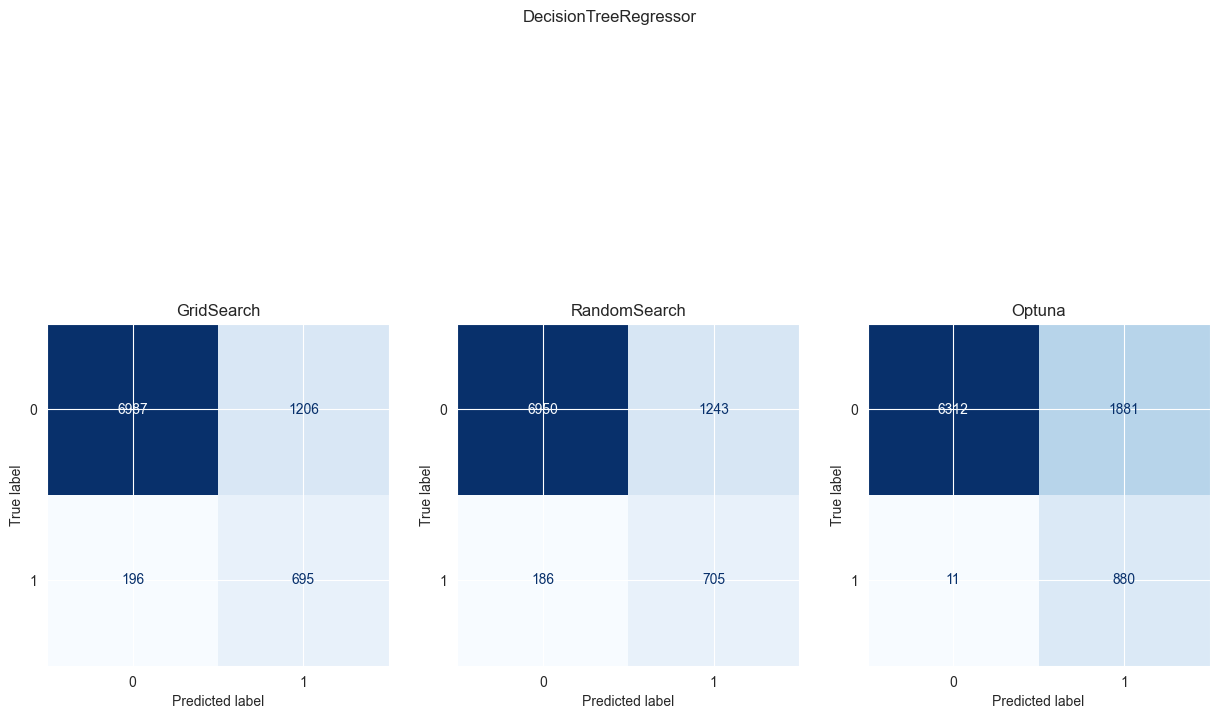

In [37]:
from sklearn.metrics import ConfusionMatrixDisplay
fig, axes = plt.subplots(1, 3, figsize=(15, 10))

for ax, (name_of_method, model_info) in zip(axes, dt_models["DT"].items()):
    model = model_info["model"]
    predict = model.predict(X_test)
    name_of_model = f"DecisionTreeRegressor ({name_of_method})"

    input_into_table(X_train, X_test, y_train, y_test, model, name_of_model)

    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap=plt.cm.Blues, ax=ax, colorbar=False)


    ax.set_title(name_of_method)

plt.suptitle("DecisionTreeRegressor")

In [32]:
train_and_test_comparing

Train Data                             \
                                             F1 Accuracy Precision  Recall   
DecisionTreeRegressor (GridSearch)         0.64   0.8941    0.4781  0.9805   
DecisionTreeRegressor (RandomSearch)       0.61   0.8816    0.4490  0.9621   
DecisionTreeRegressor (Optuna)             0.47   0.7859    0.3103  0.9830   

                                     Test Data                             
                                            F1 Accuracy Precision  Recall  
DecisionTreeRegressor (GridSearch)        0.50   0.8457    0.3656  0.7800  
DecisionTreeRegressor (RandomSearch)      0.50   0.8427    0.3619  0.7912  
DecisionTreeRegressor (Optuna)            0.48   0.7917    0.3187  0.9877

Заметим, что наилучшие результаты настройки гиперпараметров у GridSearch и RandomSearch (F1 = 0.50), хотя наиболее высокое значение Recall показал Optuna (0.9877).

### Случайный лес

In [33]:
from sklearnex.ensemble import RandomForestClassifier

rf_config = {
    "RF": {
        "model": RandomForestClassifier,
        "param_grid": {
            "n_estimators": [100, 200],
            "criterion": ["gini", "entropy"],
            "max_depth": [None, 10, 20],
            "min_samples_leaf": [1, 4],
            "max_features": ["sqrt", "log2"],
            "bootstrap": [True]
        }
    }
}

In [34]:
rf_models = train_models_with_cross_val(X_train, y_train, rf_config)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Fitting 5 folds for each of 10 candidates, totalling 50 fits


[I 2026-04-19 12:04:04,828] A new study created in memory with name: no-name-dfb95b0f-6991-460a-bffa-8d168924b9b9
[I 2026-04-19 12:04:10,296] Trial 0 finished with value: 0.4885294137418952 and parameters: {'n_estimators': 200, 'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 4, 'max_features': 'log2', 'bootstrap': True}. Best is trial 0 with value: 0.4885294137418952.
[I 2026-04-19 12:05:13,934] Trial 1 finished with value: 0.4864688537753167 and parameters: {'n_estimators': 100, 'criterion': 'entropy', 'max_depth': 20, 'min_samples_leaf': 4, 'max_features': 'log2', 'bootstrap': True}. Best is trial 0 with value: 0.4885294137418952.
[I 2026-04-19 12:05:18,820] Trial 2 finished with value: 0.4759600913388085 and parameters: {'n_estimators': 200, 'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 0 with value: 0.4885294137418952.
[I 2026-04-19 12:07:40,150] Trial 3 finished with value: 0.5017223818977197 and 

Text(0.5, 0.98, 'Random Forest')

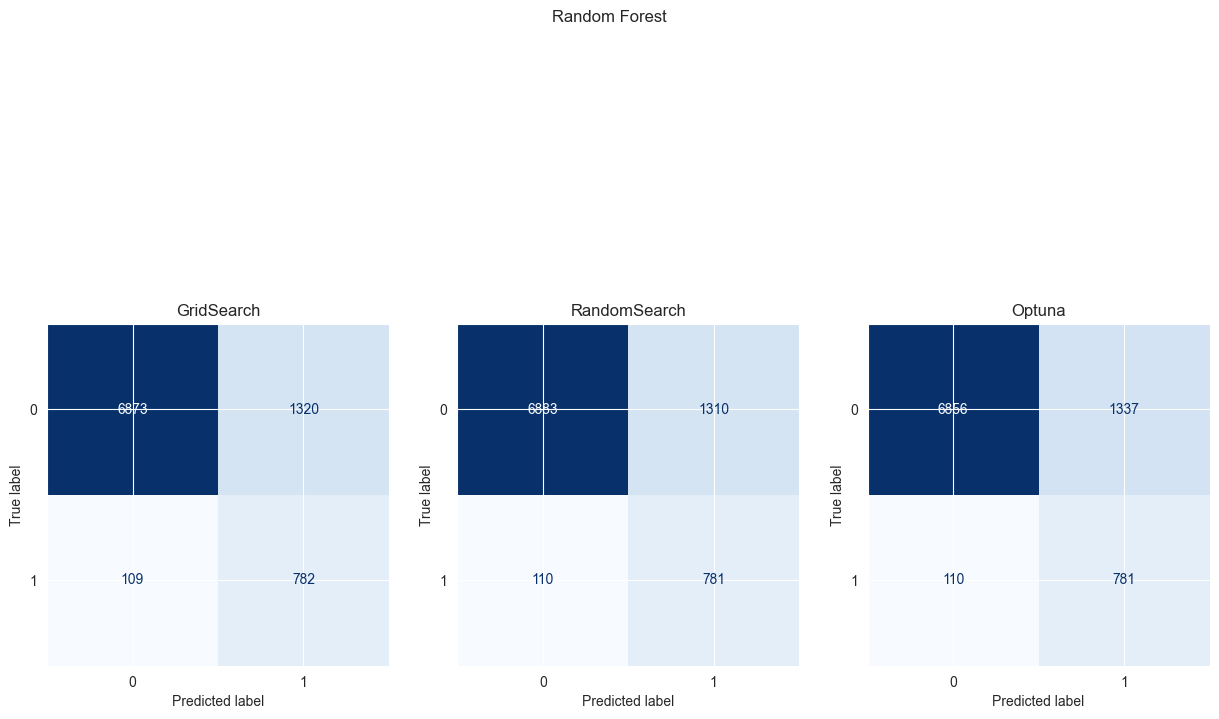

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(15, 10))

for ax, (name_of_method, model_info) in zip(axes, rf_models["RF"].items()):
    model = model_info["model"]
    predict = model.predict(X_test)
    name_of_model = f"Random Forest ({name_of_method})"

    input_into_table(X_train, X_test, y_train, y_test, model, name_of_model)

    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap=plt.cm.Blues, ax=ax, colorbar=False)


    ax.set_title(name_of_method)

plt.suptitle("Random Forest")

In [39]:
train_and_test_comparing

Train Data                             \
                                             F1 Accuracy Precision  Recall   
DecisionTreeRegressor (GridSearch)         0.64   0.8941    0.4781  0.9805   
DecisionTreeRegressor (RandomSearch)       0.61   0.8816    0.4490  0.9621   
DecisionTreeRegressor (Optuna)             0.47   0.7859    0.3103  0.9830   
Random Forest (GridSearch)                 0.62   0.8836    0.4545  0.9871   
Random Forest (RandomSearch)               0.62   0.8824    0.4520  0.9870   
Random Forest (Optuna)                     0.62   0.8828    0.4527  0.9871   

                                     Test Data                             
                                            F1 Accuracy Precision  Recall  
DecisionTreeRegressor (GridSearch)        0.50   0.8457    0.3656  0.7800  
DecisionTreeRegressor (RandomSearch)      0.50   0.8427    0.3619  0.7912  
DecisionTreeRegressor (Optuna)            0.48   0.7917    0.3187  0.9877  
Random Forest (GridSearch)                0.52   0.8427    0.3720  0.8777  
Random Forest (RandomSearch)              0.52   0.8437    0.3735  0.8765  
Random Forest (Optuna)                    0.52   0.8407    0.3687  0.8765

Случайный лес увеличил показатель метрики F1 до 0.52, но при этом показатель Recall уменьшился примерно до 0.87.

### Бэггинг-регрессор

Для бэггинга используем лучшую модель, полученную в ЛР3 на основе наивного байесовского алгоритма.

Text(0.5, 1.0, 'Bagging Classifier')

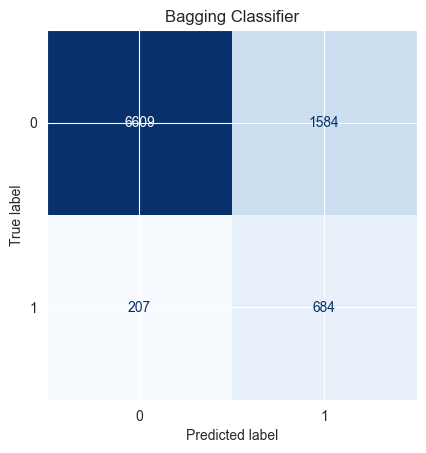

In [49]:
from sklearn.naive_bayes import GaussianNB

bag_class = BaggingClassifier(estimator=GaussianNB(var_smoothing=1e-9 ), random_state=RANDOM_STATE)

bag_class.fit(X_train, y_train)
input_into_table(X_train, X_test, y_train, y_test, bag_class, "Bagging classifier")

ConfusionMatrixDisplay.from_estimator(bag_class, X_test, y_test, cmap=plt.cm.Blues, colorbar=False)

plt.title("Bagging Classifier")

In [50]:
train_and_test_comparing

Train Data                             \
                                             F1 Accuracy Precision  Recall   
DecisionTreeRegressor (GridSearch)         0.64   0.8941    0.4781  0.9805   
DecisionTreeRegressor (RandomSearch)       0.61   0.8816    0.4490  0.9621   
DecisionTreeRegressor (Optuna)             0.47   0.7859    0.3103  0.9830   
Random Forest (GridSearch)                 0.62   0.8836    0.4545  0.9871   
Random Forest (RandomSearch)               0.62   0.8824    0.4520  0.9870   
Random Forest (Optuna)                     0.62   0.8828    0.4527  0.9871   
Bagging classifier                         0.43   0.8005    0.2968  0.7684   

                                     Test Data                             
                                            F1 Accuracy Precision  Recall  
DecisionTreeRegressor (GridSearch)        0.50   0.8457    0.3656  0.7800  
DecisionTreeRegressor (RandomSearch)      0.50   0.8427    0.3619  0.7912  
DecisionTreeRegressor (Optuna)            0.48   0.7917    0.3187  0.9877  
Random Forest (GridSearch)                0.52   0.8427    0.3720  0.8777  
Random Forest (RandomSearch)              0.52   0.8437    0.3735  0.8765  
Random Forest (Optuna)                    0.52   0.8407    0.3687  0.8765  
Bagging classifier                        0.43   0.8028    0.3016  0.7677

Использование бэггинга не привело к улучшению модели - напротив, показатель ее метрик ухудшились (так, F1 уменьшился до 0.43).

### GradientBoosting

In [11]:
from sklearnex import patch_sklearn
patch_sklearn()
from sklearn.ensemble import GradientBoostingClassifier

gb_config = {
    "Gradient Boosting": {
        "model": GradientBoostingClassifier,
        "param_grid": {
            'n_estimators': [100, 200],
            'learning_rate': [0.01, 0.05, 0.1],
            'max_depth': [3, 5, 8],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
        }
    }
}

Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


In [12]:
gb_models = train_models_with_cross_val(X_train, y_train, gb_config)

Fitting 5 folds for each of 162 candidates, totalling 810 fits
Fitting 5 folds for each of 10 candidates, totalling 50 fits


[I 2026-04-19 19:05:32,558] A new study created in memory with name: no-name-049d6455-05a1-4b49-be05-1caa40fd5089
[I 2026-04-19 19:08:17,819] Trial 0 finished with value: 0.47992930673041345 and parameters: {'n_estimators': 200, 'learning_rate': 0.07572810582874655, 'max_depth': 5, 'min_samples_split': 2, 'min_samples_leaf': 4}. Best is trial 0 with value: 0.47992930673041345.
[I 2026-04-19 19:12:23,834] Trial 1 finished with value: 0.4806868062290306 and parameters: {'n_estimators': 200, 'learning_rate': 0.033614442008866235, 'max_depth': 8, 'min_samples_split': 10, 'min_samples_leaf': 1}. Best is trial 1 with value: 0.4806868062290306.
[I 2026-04-19 19:16:25,608] Trial 2 finished with value: 0.4802761588592187 and parameters: {'n_estimators': 200, 'learning_rate': 0.02950560841959765, 'max_depth': 8, 'min_samples_split': 5, 'min_samples_leaf': 1}. Best is trial 1 with value: 0.4806868062290306.
[I 2026-04-19 19:17:18,539] Trial 3 finished with value: 0.4736514652966533 and parameters

In [18]:
import pickle
with open("table.pkl", "rb") as f:
    train_and_test_comparing = pickle.load(f)

Text(0.5, 0.98, 'Gradient Boosting')

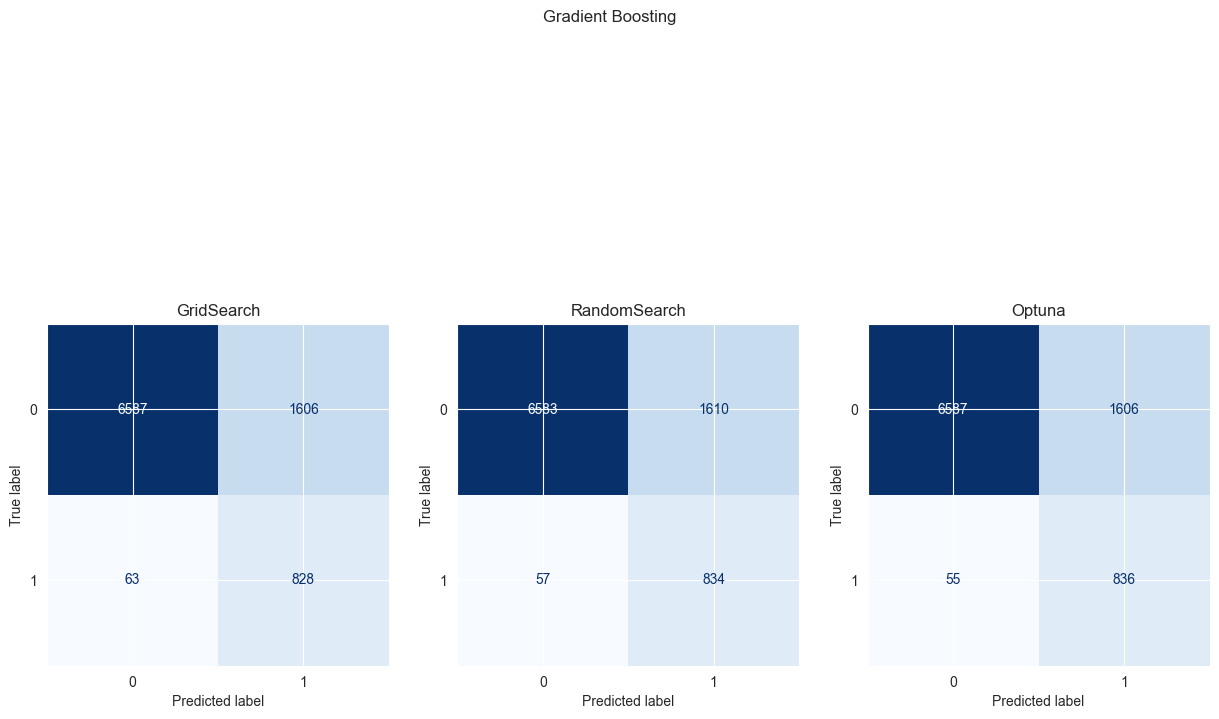

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 10))

for ax, (name_of_method, model_info) in zip(axes, gb_models["Gradient Boosting"].items()):
    model = model_info["model"]
    predict = model.predict(X_test)
    name_of_model = f"Gradient Boosting ({name_of_method})"

    input_into_table(X_train, X_test, y_train, y_test, model, name_of_model)

    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap=plt.cm.Blues, ax=ax, colorbar=False)


    ax.set_title(name_of_method)

plt.suptitle("Gradient Boosting")

In [20]:
train_and_test_comparing

Train Data                             \
                                             F1 Accuracy Precision  Recall   
DecisionTreeRegressor (GridSearch)         0.64   0.8941    0.4781  0.9805   
DecisionTreeRegressor (RandomSearch)       0.61   0.8816    0.4490  0.9621   
DecisionTreeRegressor (Optuna)             0.47   0.7859    0.3103  0.9830   
Random Forest (GridSearch)                 0.62   0.8836    0.4545  0.9871   
Random Forest (RandomSearch)               0.62   0.8824    0.4520  0.9870   
Random Forest (Optuna)                     0.62   0.8828    0.4527  0.9871   
Bagging classifier                         0.43   0.8005    0.2968  0.7684   
Gradient Boosting (GridSearch)             0.53   0.8321    0.3652  0.9858   
Gradient Boosting (RandomSearch)           0.53   0.8327    0.3661  0.9858   
Gradient Boosting (Optuna)                 0.53   0.8312    0.3640  0.9850   

                                     Test Data                             
                                            F1 Accuracy Precision  Recall  
DecisionTreeRegressor (GridSearch)        0.50   0.8457    0.3656  0.7800  
DecisionTreeRegressor (RandomSearch)      0.50   0.8427    0.3619  0.7912  
DecisionTreeRegressor (Optuna)            0.48   0.7917    0.3187  0.9877  
Random Forest (GridSearch)                0.52   0.8427    0.3720  0.8777  
Random Forest (RandomSearch)              0.52   0.8437    0.3735  0.8765  
Random Forest (Optuna)                    0.52   0.8407    0.3687  0.8765  
Bagging classifier                        0.43   0.8028    0.3016  0.7677  
Gradient Boosting (GridSearch)            0.50   0.8163    0.3402  0.9293  
Gradient Boosting (RandomSearch)          0.50   0.8165    0.3412  0.9360  
Gradient Boosting (Optuna)                0.50   0.8172    0.3423  0.9383

Заметим, что среди ансамблевых моделей градиентной бустинг показал один из лучших результатов по метрике F1 (0.50) и Recall (примерно 0.93).

### AdaBoost

In [11]:
ab_config = {
    "AdaBoost": {
        "model": AdaBoostClassifier,
        "param_grid": {
            'n_estimators': [50, 100, 200, 500],
            'learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0],
        }
    }
}

In [12]:
ab_models = train_models_with_cross_val(X_train, y_train, ab_config)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 10 candidates, totalling 50 fits


[I 2026-04-20 16:40:38,388] A new study created in memory with name: no-name-81ce638d-a945-4b9d-9a5b-f4b676e6f8a3
[I 2026-04-20 16:41:03,534] Trial 0 finished with value: 0.4582321916301123 and parameters: {'n_estimators': 100, 'learning_rate': 0.35864999914850715}. Best is trial 0 with value: 0.4582321916301123.
[I 2026-04-20 16:43:03,537] Trial 1 finished with value: 0.4692162742050666 and parameters: {'n_estimators': 500, 'learning_rate': 0.6229361563509381}. Best is trial 1 with value: 0.4692162742050666.
[I 2026-04-20 16:44:59,839] Trial 2 finished with value: 0.46771601119263073 and parameters: {'n_estimators': 500, 'learning_rate': 0.22020213985214743}. Best is trial 1 with value: 0.4692162742050666.
[I 2026-04-20 16:45:46,579] Trial 3 finished with value: 0.46876733672073084 and parameters: {'n_estimators': 200, 'learning_rate': 0.8051303336786382}. Best is trial 1 with value: 0.4692162742050666.
[I 2026-04-20 16:46:11,761] Trial 4 finished with value: 0.46844425355248587 and p

Text(0.5, 0.98, 'AdaBoost')

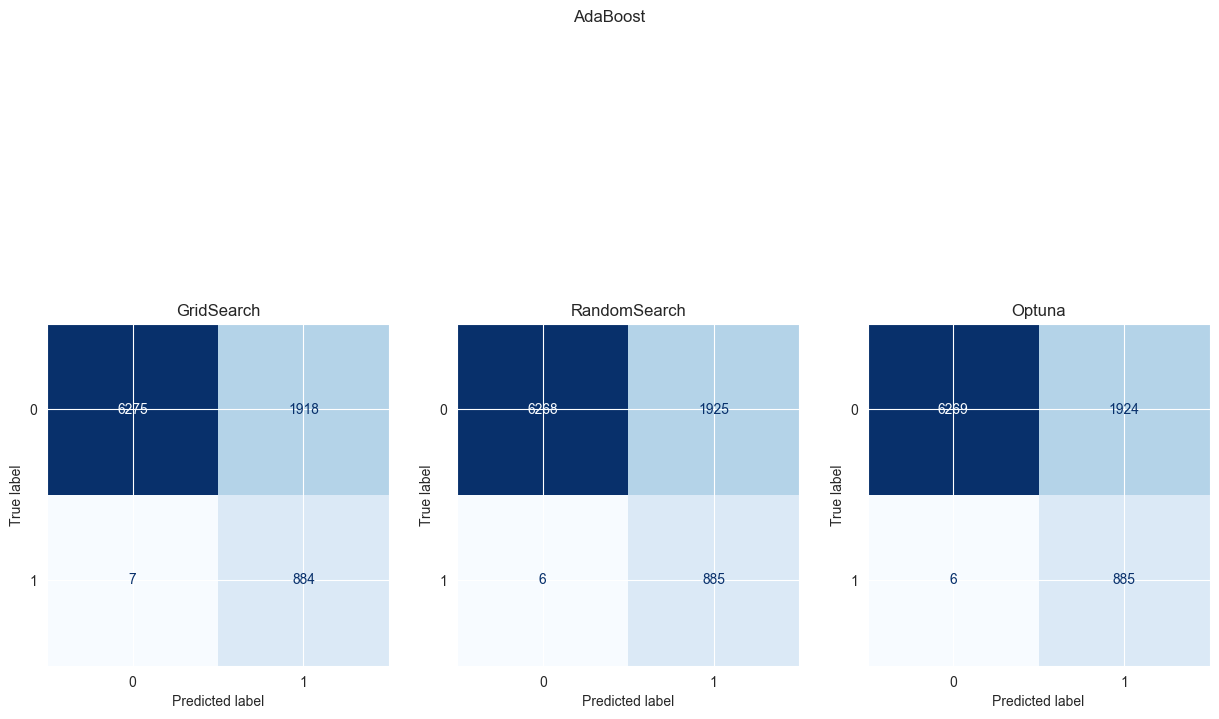

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 10))

for ax, (name_of_method, model_info) in zip(axes, ab_models["AdaBoost"].items()):
    model = model_info["model"]
    predict = model.predict(X_test)
    name_of_model = f"AdaBoost ({name_of_method})"

    input_into_table(X_train, X_test, y_train, y_test, model, name_of_model)

    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap=plt.cm.Blues, ax=ax, colorbar=False)


    ax.set_title(name_of_method)

plt.suptitle("AdaBoost")

In [18]:
train_and_test_comparing

Train Data                             \
                                             F1 Accuracy Precision  Recall   
DecisionTreeRegressor (GridSearch)         0.64   0.8941    0.4781  0.9805   
DecisionTreeRegressor (RandomSearch)       0.61   0.8816    0.4490  0.9621   
DecisionTreeRegressor (Optuna)             0.47   0.7859    0.3103  0.9830   
Random Forest (GridSearch)                 0.62   0.8836    0.4545  0.9871   
Random Forest (RandomSearch)               0.62   0.8824    0.4520  0.9870   
Random Forest (Optuna)                     0.62   0.8828    0.4527  0.9871   
Bagging classifier                         0.43   0.8005    0.2968  0.7684   
Gradient Boosting (GridSearch)             0.53   0.8321    0.3652  0.9858   
Gradient Boosting (RandomSearch)           0.53   0.8327    0.3661  0.9858   
Gradient Boosting (Optuna)                 0.53   0.8312    0.3640  0.9850   
AdaBoost (GridSearch)                      0.47   0.7823    0.3075  0.9907   
AdaBoost (RandomSearch)                    0.47   0.7813    0.3067  0.9912   
AdaBoost (Optuna)                          0.47   0.7816    0.3069  0.9911   

                                     Test Data                             
                                            F1 Accuracy Precision  Recall  
DecisionTreeRegressor (GridSearch)        0.50   0.8457    0.3656  0.7800  
DecisionTreeRegressor (RandomSearch)      0.50   0.8427    0.3619  0.7912  
DecisionTreeRegressor (Optuna)            0.48   0.7917    0.3187  0.9877  
Random Forest (GridSearch)                0.52   0.8427    0.3720  0.8777  
Random Forest (RandomSearch)              0.52   0.8437    0.3735  0.8765  
Random Forest (Optuna)                    0.52   0.8407    0.3687  0.8765  
Bagging classifier                        0.43   0.8028    0.3016  0.7677  
Gradient Boosting (GridSearch)            0.50   0.8163    0.3402  0.9293  
Gradient Boosting (RandomSearch)          0.50   0.8165    0.3412  0.9360  
Gradient Boosting (Optuna)                0.50   0.8172    0.3423  0.9383  
AdaBoost (GridSearch)                     0.48   0.7881    0.3155  0.9921  
AdaBoost (RandomSearch)                   0.48   0.7874    0.3149  0.9933  
AdaBoost (Optuna)                         0.48   0.7875    0.3151  0.9933

Заметим, что модель AdaBoost показала наибольшее значение метрики Recall среди всех ансамблевых моделей (около 0.99).

### Stacking

Для стэкинга будем использовать разнородные модели - модель AdaBoost и наивную байесовскую модель.

In [21]:
from sklearn.ensemble import StackingClassifier

base_models = [
    ('adaboost', AdaBoostClassifier(
        n_estimators=500,
        learning_rate=0.6229361563509381,
        random_state=42
    )),
    ('gnb', GaussianNB())
]

stacking_model = StackingClassifier(base_models)
stacking_model.fit(X_train, y_train)

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('adaboost', ...), ('gnb', ...)]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",None
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",None
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'auto'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",None
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",500
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between th

Text(0.5, 1.0, 'Stacking Classifier')

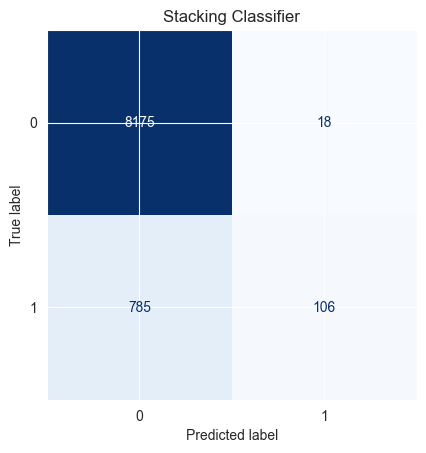

In [22]:
ConfusionMatrixDisplay.from_estimator(stacking_model, X_test, y_test, cmap=plt.cm.Blues, colorbar=False)

plt.title("Stacking Classifier")

In [23]:
input_into_table(X_train, X_test, y_train, y_test, stacking_model, "Stacking classifier")
train_and_test_comparing

Train Data                             \
                                             F1 Accuracy Precision  Recall   
DecisionTreeRegressor (GridSearch)         0.64   0.8941    0.4781  0.9805   
DecisionTreeRegressor (RandomSearch)       0.61   0.8816    0.4490  0.9621   
DecisionTreeRegressor (Optuna)             0.47   0.7859    0.3103  0.9830   
Random Forest (GridSearch)                 0.62   0.8836    0.4545  0.9871   
Random Forest (RandomSearch)               0.62   0.8824    0.4520  0.9870   
Random Forest (Optuna)                     0.62   0.8828    0.4527  0.9871   
Bagging classifier                         0.43   0.8005    0.2968  0.7684   
Gradient Boosting (GridSearch)             0.53   0.8321    0.3652  0.9858   
Gradient Boosting (RandomSearch)           0.53   0.8327    0.3661  0.9858   
Gradient Boosting (Optuna)                 0.53   0.8312    0.3640  0.9850   
AdaBoost (GridSearch)                      0.47   0.7823    0.3075  0.9907   
AdaBoost (RandomSearch)                    0.47   0.7813    0.3067  0.9912   
AdaBoost (Optuna)                          0.47   0.7816    0.3069  0.9911   
Stacking classifier                        0.21   0.9125    0.8735  0.1164   

                                     Test Data                             
                                            F1 Accuracy Precision  Recall  
DecisionTreeRegressor (GridSearch)        0.50   0.8457    0.3656  0.7800  
DecisionTreeRegressor (RandomSearch)      0.50   0.8427    0.3619  0.7912  
DecisionTreeRegressor (Optuna)            0.48   0.7917    0.3187  0.9877  
Random Forest (GridSearch)                0.52   0.8427    0.3720  0.8777  
Random Forest (RandomSearch)              0.52   0.8437    0.3735  0.8765  
Random Forest (Optuna)                    0.52   0.8407    0.3687  0.8765  
Bagging classifier                        0.43   0.8028    0.3016  0.7677  
Gradient Boosting (GridSearch)            0.50   0.8163    0.3402  0.9293  
Gradient Boosting (RandomSearch)          0.50   0.8165    0.3412  0.9360  
Gradient Boosting (Optuna)                0.50   0.8172    0.3423  0.9383  
AdaBoost (GridSearch)                     0.48   0.7881    0.3155  0.9921  
AdaBoost (RandomSearch)                   0.48   0.7874    0.3149  0.9933  
AdaBoost (Optuna)                         0.48   0.7875    0.3151  0.9933  
Stacking classifier                       0.21   0.9116    0.8548  0.1190

Заметим, что модель стала работать гораздо хуже по метрике Recall (0.1190).

Но стоит отметить, что эта модель обладает высоким precision (0.8548).

### CatBoost

In [27]:
cb_config = {
    "CatBoost": {
        "model": CatBoostClassifier,
        "param_grid": {
                'iterations': [100, 200, 300, 400, 500],
                'learning_rate': [0.01, 0.05, 0.1],
                'depth': [4, 6, 8],
                'l2_leaf_reg': [1, 3, 5, 7, 9],
        }
    }
}

In [28]:
cb_models = train_models_with_cross_val(X_train, y_train, cb_config)

Fitting 5 folds for each of 225 candidates, totalling 1125 fits
0:	learn: 0.5178069	total: 156ms	remaining: 1m 17s
1:	learn: 0.4058636	total: 167ms	remaining: 41.7s
2:	learn: 0.3296336	total: 180ms	remaining: 29.9s
3:	learn: 0.2693306	total: 193ms	remaining: 23.9s
4:	learn: 0.2383069	total: 205ms	remaining: 20.3s
5:	learn: 0.2119396	total: 217ms	remaining: 17.8s
6:	learn: 0.1932918	total: 228ms	remaining: 16s
7:	learn: 0.1796657	total: 239ms	remaining: 14.7s
8:	learn: 0.1696301	total: 250ms	remaining: 13.7s
9:	learn: 0.1626466	total: 261ms	remaining: 12.8s
10:	learn: 0.1575826	total: 273ms	remaining: 12.1s
11:	learn: 0.1540784	total: 285ms	remaining: 11.6s
12:	learn: 0.1514412	total: 296ms	remaining: 11.1s
13:	learn: 0.1492165	total: 307ms	remaining: 10.6s
14:	learn: 0.1471895	total: 318ms	remaining: 10.3s
15:	learn: 0.1457209	total: 329ms	remaining: 9.97s
16:	learn: 0.1443866	total: 341ms	remaining: 9.7s
17:	learn: 0.1433609	total: 353ms	remaining: 9.45s
18:	learn: 0.1424376	total: 36

[I 2026-04-20 18:07:26,917] A new study created in memory with name: no-name-efc41013-c434-43d4-ac75-a90dce2760e7


488:	learn: 0.0985881	total: 4.65s	remaining: 105ms
489:	learn: 0.0985520	total: 4.66s	remaining: 95.2ms
490:	learn: 0.0985135	total: 4.67s	remaining: 85.6ms
491:	learn: 0.0984591	total: 4.68s	remaining: 76.1ms
492:	learn: 0.0983701	total: 4.69s	remaining: 66.6ms
493:	learn: 0.0983415	total: 4.7s	remaining: 57.1ms
494:	learn: 0.0983104	total: 4.71s	remaining: 47.6ms
495:	learn: 0.0982892	total: 4.72s	remaining: 38ms
496:	learn: 0.0982440	total: 4.72s	remaining: 28.5ms
497:	learn: 0.0982040	total: 4.74s	remaining: 19ms
498:	learn: 0.0981774	total: 4.74s	remaining: 9.5ms
499:	learn: 0.0981338	total: 4.75s	remaining: 0us
0:	learn: 0.5410800	total: 7.3ms	remaining: 1.45s
1:	learn: 0.4381704	total: 13.6ms	remaining: 1.34s
2:	learn: 0.3646077	total: 19.7ms	remaining: 1.29s
3:	learn: 0.3063735	total: 27.5ms	remaining: 1.35s
4:	learn: 0.2627268	total: 33.5ms	remaining: 1.31s
5:	learn: 0.2415068	total: 39.7ms	remaining: 1.28s
6:	learn: 0.2219371	total: 46.1ms	remaining: 1.27s
7:	learn: 0.207509

[I 2026-04-20 18:07:37,039] Trial 0 finished with value: 0.4746059550414402 and parameters: {'iterations': 200, 'learning_rate': 0.08495567898311768, 'depth': 4, 'l2_leaf_reg': 9}. Best is trial 0 with value: 0.4746059550414402.


197:	learn: 0.1257243	total: 1.26s	remaining: 12.7ms
198:	learn: 0.1256744	total: 1.27s	remaining: 6.37ms
199:	learn: 0.1256261	total: 1.27s	remaining: 0us
0:	learn: 0.6371668	total: 10.7ms	remaining: 2.13s
1:	learn: 0.5876186	total: 21ms	remaining: 2.08s
2:	learn: 0.5417010	total: 31.8ms	remaining: 2.09s
3:	learn: 0.5009409	total: 41.9ms	remaining: 2.05s
4:	learn: 0.4649261	total: 51.9ms	remaining: 2.02s
5:	learn: 0.4291937	total: 61.9ms	remaining: 2s
6:	learn: 0.3958848	total: 71.9ms	remaining: 1.98s
7:	learn: 0.3707351	total: 82.3ms	remaining: 1.98s
8:	learn: 0.3497402	total: 92.3ms	remaining: 1.96s
9:	learn: 0.3273268	total: 103ms	remaining: 1.95s
10:	learn: 0.3086486	total: 113ms	remaining: 1.95s
11:	learn: 0.2934283	total: 124ms	remaining: 1.94s
12:	learn: 0.2793887	total: 134ms	remaining: 1.93s
13:	learn: 0.2673584	total: 144ms	remaining: 1.92s
14:	learn: 0.2573728	total: 155ms	remaining: 1.91s
15:	learn: 0.2494611	total: 165ms	remaining: 1.9s
16:	learn: 0.2419420	total: 175ms	r

[I 2026-04-20 18:07:51,227] Trial 1 finished with value: 0.47508788355935716 and parameters: {'iterations': 200, 'learning_rate': 0.028555102508559027, 'depth': 8, 'l2_leaf_reg': 7}. Best is trial 1 with value: 0.47508788355935716.


0:	learn: 0.6102811	total: 6.16ms	remaining: 1.84s
1:	learn: 0.5442002	total: 12.2ms	remaining: 1.82s
2:	learn: 0.4861022	total: 18.4ms	remaining: 1.83s
3:	learn: 0.4276363	total: 24.1ms	remaining: 1.78s
4:	learn: 0.3805972	total: 30ms	remaining: 1.77s
5:	learn: 0.3486941	total: 35.7ms	remaining: 1.75s
6:	learn: 0.3235632	total: 41.4ms	remaining: 1.73s
7:	learn: 0.3024800	total: 47.6ms	remaining: 1.74s
8:	learn: 0.2871036	total: 52.9ms	remaining: 1.71s
9:	learn: 0.2694287	total: 58.7ms	remaining: 1.7s
10:	learn: 0.2544577	total: 64.9ms	remaining: 1.71s
11:	learn: 0.2428284	total: 70.7ms	remaining: 1.7s
12:	learn: 0.2302927	total: 77.2ms	remaining: 1.7s
13:	learn: 0.2219660	total: 83.2ms	remaining: 1.7s
14:	learn: 0.2124466	total: 89.1ms	remaining: 1.69s
15:	learn: 0.2029085	total: 95.2ms	remaining: 1.69s
16:	learn: 0.1979491	total: 101ms	remaining: 1.69s
17:	learn: 0.1921777	total: 108ms	remaining: 1.69s
18:	learn: 0.1881422	total: 114ms	remaining: 1.69s
19:	learn: 0.1826898	total: 120

[I 2026-04-20 18:08:04,502] Trial 2 finished with value: 0.47412397523069283 and parameters: {'iterations': 300, 'learning_rate': 0.04275838114562094, 'depth': 4, 'l2_leaf_reg': 1}. Best is trial 1 with value: 0.47508788355935716.


0:	learn: 0.6558212	total: 6.66ms	remaining: 1.32s
1:	learn: 0.6226745	total: 12.7ms	remaining: 1.26s
2:	learn: 0.5907700	total: 19.4ms	remaining: 1.27s
3:	learn: 0.5600145	total: 25.4ms	remaining: 1.25s
4:	learn: 0.5253696	total: 31.6ms	remaining: 1.23s
5:	learn: 0.5006805	total: 37.7ms	remaining: 1.22s
6:	learn: 0.4785186	total: 43.5ms	remaining: 1.2s
7:	learn: 0.4571629	total: 50.1ms	remaining: 1.2s
8:	learn: 0.4383257	total: 56.3ms	remaining: 1.2s
9:	learn: 0.4206636	total: 61.7ms	remaining: 1.17s
10:	learn: 0.3972830	total: 68.2ms	remaining: 1.17s
11:	learn: 0.3828974	total: 74.1ms	remaining: 1.16s
12:	learn: 0.3663122	total: 80.2ms	remaining: 1.15s
13:	learn: 0.3535950	total: 86.7ms	remaining: 1.15s
14:	learn: 0.3412367	total: 92.7ms	remaining: 1.14s
15:	learn: 0.3258384	total: 99.5ms	remaining: 1.14s
16:	learn: 0.3160621	total: 105ms	remaining: 1.13s
17:	learn: 0.3067398	total: 111ms	remaining: 1.13s
18:	learn: 0.2992246	total: 118ms	remaining: 1.12s
19:	learn: 0.2920825	total: 

[I 2026-04-20 18:08:14,073] Trial 3 finished with value: 0.4714976481188825 and parameters: {'iterations': 200, 'learning_rate': 0.018599639488359597, 'depth': 4, 'l2_leaf_reg': 1}. Best is trial 1 with value: 0.47508788355935716.


180:	learn: 0.1400564	total: 1.27s	remaining: 133ms
181:	learn: 0.1400235	total: 1.27s	remaining: 126ms
182:	learn: 0.1399720	total: 1.28s	remaining: 119ms
183:	learn: 0.1399356	total: 1.28s	remaining: 112ms
184:	learn: 0.1398737	total: 1.29s	remaining: 105ms
185:	learn: 0.1398148	total: 1.3s	remaining: 97.7ms
186:	learn: 0.1397780	total: 1.3s	remaining: 90.6ms
187:	learn: 0.1397505	total: 1.31s	remaining: 83.5ms
188:	learn: 0.1397230	total: 1.31s	remaining: 76.5ms
189:	learn: 0.1396914	total: 1.32s	remaining: 69.5ms
190:	learn: 0.1396591	total: 1.33s	remaining: 62.6ms
191:	learn: 0.1396146	total: 1.33s	remaining: 55.6ms
192:	learn: 0.1395908	total: 1.34s	remaining: 48.6ms
193:	learn: 0.1395659	total: 1.35s	remaining: 41.6ms
194:	learn: 0.1395290	total: 1.35s	remaining: 34.7ms
195:	learn: 0.1395079	total: 1.36s	remaining: 27.7ms
196:	learn: 0.1394704	total: 1.36s	remaining: 20.8ms
197:	learn: 0.1394375	total: 1.37s	remaining: 13.8ms
198:	learn: 0.1393869	total: 1.38s	remaining: 6.91ms


[I 2026-04-20 18:08:33,422] Trial 4 finished with value: 0.47662158155787954 and parameters: {'iterations': 400, 'learning_rate': 0.049855421627111346, 'depth': 6, 'l2_leaf_reg': 1}. Best is trial 4 with value: 0.47662158155787954.


377:	learn: 0.1121781	total: 2.95s	remaining: 172ms
378:	learn: 0.1121398	total: 2.96s	remaining: 164ms
379:	learn: 0.1120680	total: 2.96s	remaining: 156ms
380:	learn: 0.1120222	total: 2.97s	remaining: 148ms
381:	learn: 0.1119069	total: 2.98s	remaining: 140ms
382:	learn: 0.1118541	total: 2.99s	remaining: 133ms
383:	learn: 0.1118118	total: 2.99s	remaining: 125ms
384:	learn: 0.1117911	total: 3s	remaining: 117ms
385:	learn: 0.1117509	total: 3.01s	remaining: 109ms
386:	learn: 0.1116544	total: 3.02s	remaining: 101ms
387:	learn: 0.1116283	total: 3.02s	remaining: 93.6ms
388:	learn: 0.1115591	total: 3.03s	remaining: 85.8ms
389:	learn: 0.1115140	total: 3.04s	remaining: 78ms
390:	learn: 0.1114617	total: 3.05s	remaining: 70.2ms
391:	learn: 0.1113924	total: 3.06s	remaining: 62.4ms
392:	learn: 0.1113457	total: 3.06s	remaining: 54.6ms
393:	learn: 0.1112877	total: 3.07s	remaining: 46.8ms
394:	learn: 0.1112396	total: 3.08s	remaining: 39ms
395:	learn: 0.1111891	total: 3.09s	remaining: 31.2ms
396:	learn

[I 2026-04-20 18:08:47,891] Trial 5 finished with value: 0.47866866691605603 and parameters: {'iterations': 200, 'learning_rate': 0.09928040475142903, 'depth': 8, 'l2_leaf_reg': 1}. Best is trial 5 with value: 0.47866866691605603.


196:	learn: 0.0983563	total: 2.15s	remaining: 32.7ms
197:	learn: 0.0981834	total: 2.16s	remaining: 21.8ms
198:	learn: 0.0979796	total: 2.17s	remaining: 10.9ms
199:	learn: 0.0977601	total: 2.18s	remaining: 0us
0:	learn: 0.6664198	total: 7.74ms	remaining: 3.09s
1:	learn: 0.6409552	total: 15.3ms	remaining: 3.05s
2:	learn: 0.6144028	total: 22.4ms	remaining: 2.97s
3:	learn: 0.5905030	total: 30.8ms	remaining: 3.04s
4:	learn: 0.5687825	total: 38.3ms	remaining: 3.02s
5:	learn: 0.5483512	total: 46.3ms	remaining: 3.04s
6:	learn: 0.5298912	total: 53.4ms	remaining: 3s
7:	learn: 0.5113735	total: 61.3ms	remaining: 3s
8:	learn: 0.4912800	total: 68.8ms	remaining: 2.99s
9:	learn: 0.4741747	total: 76.4ms	remaining: 2.98s
10:	learn: 0.4585082	total: 83.8ms	remaining: 2.96s
11:	learn: 0.4435469	total: 91.2ms	remaining: 2.95s
12:	learn: 0.4285497	total: 99.2ms	remaining: 2.95s
13:	learn: 0.4150813	total: 107ms	remaining: 2.94s
14:	learn: 0.4045755	total: 114ms	remaining: 2.94s
15:	learn: 0.3922776	total: 1

[I 2026-04-20 18:09:06,992] Trial 6 finished with value: 0.47380133009562153 and parameters: {'iterations': 400, 'learning_rate': 0.013391990941659703, 'depth': 6, 'l2_leaf_reg': 7}. Best is trial 5 with value: 0.47866866691605603.


396:	learn: 0.1325061	total: 3.11s	remaining: 23.5ms
397:	learn: 0.1324900	total: 3.12s	remaining: 15.7ms
398:	learn: 0.1324721	total: 3.12s	remaining: 7.83ms
399:	learn: 0.1324585	total: 3.13s	remaining: 0us
0:	learn: 0.6475509	total: 7.41ms	remaining: 3.7s
1:	learn: 0.6058598	total: 14.8ms	remaining: 3.7s
2:	learn: 0.5644707	total: 21.9ms	remaining: 3.62s
3:	learn: 0.5285383	total: 28.9ms	remaining: 3.58s
4:	learn: 0.4971419	total: 36.3ms	remaining: 3.59s
5:	learn: 0.4687398	total: 43.3ms	remaining: 3.56s
6:	learn: 0.4441046	total: 50.3ms	remaining: 3.54s
7:	learn: 0.4204177	total: 57.3ms	remaining: 3.52s
8:	learn: 0.3998300	total: 64.8ms	remaining: 3.54s
9:	learn: 0.3770063	total: 71.8ms	remaining: 3.52s
10:	learn: 0.3559326	total: 79ms	remaining: 3.51s
11:	learn: 0.3421469	total: 86ms	remaining: 3.5s
12:	learn: 0.3264547	total: 93.4ms	remaining: 3.5s
13:	learn: 0.3128203	total: 101ms	remaining: 3.49s
14:	learn: 0.3021627	total: 108ms	remaining: 3.49s
15:	learn: 0.2905357	total: 115

[I 2026-04-20 18:09:29,988] Trial 7 finished with value: 0.4757464185484375 and parameters: {'iterations': 500, 'learning_rate': 0.023230602476009853, 'depth': 6, 'l2_leaf_reg': 9}. Best is trial 5 with value: 0.47866866691605603.


483:	learn: 0.1229669	total: 3.77s	remaining: 124ms
484:	learn: 0.1229291	total: 3.77s	remaining: 117ms
485:	learn: 0.1229106	total: 3.78s	remaining: 109ms
486:	learn: 0.1228692	total: 3.79s	remaining: 101ms
487:	learn: 0.1228438	total: 3.79s	remaining: 93.3ms
488:	learn: 0.1227965	total: 3.8s	remaining: 85.6ms
489:	learn: 0.1227856	total: 3.81s	remaining: 77.8ms
490:	learn: 0.1227642	total: 3.82s	remaining: 70ms
491:	learn: 0.1227306	total: 3.83s	remaining: 62.2ms
492:	learn: 0.1226850	total: 3.83s	remaining: 54.4ms
493:	learn: 0.1226410	total: 3.84s	remaining: 46.6ms
494:	learn: 0.1226161	total: 3.85s	remaining: 38.9ms
495:	learn: 0.1225887	total: 3.85s	remaining: 31.1ms
496:	learn: 0.1225670	total: 3.86s	remaining: 23.3ms
497:	learn: 0.1225436	total: 3.87s	remaining: 15.5ms
498:	learn: 0.1225120	total: 3.88s	remaining: 7.77ms
499:	learn: 0.1224667	total: 3.89s	remaining: 0us
0:	learn: 0.5970553	total: 14.5ms	remaining: 5.8s
1:	learn: 0.5196142	total: 28.9ms	remaining: 5.76s
2:	learn

[I 2026-04-20 18:09:55,878] Trial 8 finished with value: 0.47755231935560305 and parameters: {'iterations': 400, 'learning_rate': 0.05030871223938552, 'depth': 8, 'l2_leaf_reg': 5}. Best is trial 5 with value: 0.47866866691605603.


385:	learn: 0.1013648	total: 4.24s	remaining: 154ms
386:	learn: 0.1013248	total: 4.25s	remaining: 143ms
387:	learn: 0.1012258	total: 4.26s	remaining: 132ms
388:	learn: 0.1011721	total: 4.27s	remaining: 121ms
389:	learn: 0.1011277	total: 4.28s	remaining: 110ms
390:	learn: 0.1010976	total: 4.29s	remaining: 98.7ms
391:	learn: 0.1010231	total: 4.3s	remaining: 87.7ms
392:	learn: 0.1009772	total: 4.31s	remaining: 76.8ms
393:	learn: 0.1008906	total: 4.32s	remaining: 65.8ms
394:	learn: 0.1008067	total: 4.33s	remaining: 54.8ms
395:	learn: 0.1007234	total: 4.34s	remaining: 43.9ms
396:	learn: 0.1006498	total: 4.35s	remaining: 32.9ms
397:	learn: 0.1005840	total: 4.36s	remaining: 21.9ms
398:	learn: 0.1004937	total: 4.37s	remaining: 11ms
399:	learn: 0.1004163	total: 4.38s	remaining: 0us
0:	learn: 0.5656531	total: 10.5ms	remaining: 5.25s
1:	learn: 0.4707911	total: 21.1ms	remaining: 5.26s
2:	learn: 0.3947246	total: 32.3ms	remaining: 5.35s
3:	learn: 0.3454833	total: 42.2ms	remaining: 5.23s
4:	learn: 0.

[I 2026-04-20 18:10:32,127] Trial 9 finished with value: 0.48050814311808543 and parameters: {'iterations': 500, 'learning_rate': 0.06808430699071993, 'depth': 8, 'l2_leaf_reg': 3}. Best is trial 9 with value: 0.48050814311808543.


498:	learn: 0.0826678	total: 5.52s	remaining: 11.1ms
499:	learn: 0.0826030	total: 5.53s	remaining: 0us
0:	learn: 0.5587107	total: 18.5ms	remaining: 9.21s
1:	learn: 0.4604698	total: 33.2ms	remaining: 8.27s
2:	learn: 0.3831894	total: 48.2ms	remaining: 7.98s
3:	learn: 0.3339136	total: 63.2ms	remaining: 7.83s
4:	learn: 0.2925381	total: 78.6ms	remaining: 7.78s
5:	learn: 0.2544170	total: 92.2ms	remaining: 7.59s
6:	learn: 0.2276507	total: 104ms	remaining: 7.34s
7:	learn: 0.2102413	total: 117ms	remaining: 7.18s
8:	learn: 0.1980779	total: 129ms	remaining: 7.05s
9:	learn: 0.1865209	total: 142ms	remaining: 6.96s
10:	learn: 0.1787069	total: 155ms	remaining: 6.87s
11:	learn: 0.1717197	total: 167ms	remaining: 6.81s
12:	learn: 0.1664820	total: 180ms	remaining: 6.75s
13:	learn: 0.1621831	total: 193ms	remaining: 6.69s
14:	learn: 0.1583241	total: 205ms	remaining: 6.64s
15:	learn: 0.1554835	total: 221ms	remaining: 6.67s
16:	learn: 0.1532301	total: 241ms	remaining: 6.85s
17:	learn: 0.1508737	total: 254ms	

[I 2026-04-20 18:11:07,439] Trial 10 finished with value: 0.48148922044458314 and parameters: {'iterations': 500, 'learning_rate': 0.07223851957081691, 'depth': 8, 'l2_leaf_reg': 3}. Best is trial 10 with value: 0.48148922044458314.


489:	learn: 0.0818228	total: 5.48s	remaining: 112ms
490:	learn: 0.0817561	total: 5.49s	remaining: 101ms
491:	learn: 0.0817203	total: 5.5s	remaining: 89.5ms
492:	learn: 0.0816577	total: 5.51s	remaining: 78.3ms
493:	learn: 0.0815836	total: 5.53s	remaining: 67.1ms
494:	learn: 0.0815375	total: 5.54s	remaining: 55.9ms
495:	learn: 0.0815000	total: 5.54s	remaining: 44.7ms
496:	learn: 0.0814054	total: 5.56s	remaining: 33.5ms
497:	learn: 0.0813413	total: 5.57s	remaining: 22.4ms
498:	learn: 0.0813120	total: 5.58s	remaining: 11.2ms
499:	learn: 0.0812302	total: 5.59s	remaining: 0us
0:	learn: 0.5566634	total: 10.5ms	remaining: 5.23s
1:	learn: 0.4574681	total: 20.8ms	remaining: 5.18s
2:	learn: 0.3798781	total: 31ms	remaining: 5.14s
3:	learn: 0.3306231	total: 41.1ms	remaining: 5.1s
4:	learn: 0.2894566	total: 51.5ms	remaining: 5.1s
5:	learn: 0.2516841	total: 61.5ms	remaining: 5.06s
6:	learn: 0.2252949	total: 71.5ms	remaining: 5.03s
7:	learn: 0.2081949	total: 81.9ms	remaining: 5.03s
8:	learn: 0.1962629

[I 2026-04-20 18:11:39,089] Trial 11 finished with value: 0.48152640647043815 and parameters: {'iterations': 500, 'learning_rate': 0.0734713919860664, 'depth': 8, 'l2_leaf_reg': 3}. Best is trial 11 with value: 0.48152640647043815.


495:	learn: 0.0806270	total: 5.55s	remaining: 44.8ms
496:	learn: 0.0805412	total: 5.56s	remaining: 33.6ms
497:	learn: 0.0804634	total: 5.58s	remaining: 22.4ms
498:	learn: 0.0803677	total: 5.59s	remaining: 11.2ms
499:	learn: 0.0802823	total: 5.6s	remaining: 0us
0:	learn: 0.5591568	total: 11.4ms	remaining: 5.7s
1:	learn: 0.4611322	total: 21.5ms	remaining: 5.35s
2:	learn: 0.3839217	total: 32.4ms	remaining: 5.37s
3:	learn: 0.3346423	total: 44.4ms	remaining: 5.5s
4:	learn: 0.2932208	total: 54.7ms	remaining: 5.42s
5:	learn: 0.2550246	total: 65.3ms	remaining: 5.38s
6:	learn: 0.2281761	total: 76.4ms	remaining: 5.38s
7:	learn: 0.2106983	total: 86.6ms	remaining: 5.33s
8:	learn: 0.1984837	total: 97.5ms	remaining: 5.32s
9:	learn: 0.1868702	total: 109ms	remaining: 5.34s
10:	learn: 0.1790166	total: 119ms	remaining: 5.31s
11:	learn: 0.1719909	total: 130ms	remaining: 5.3s
12:	learn: 0.1667210	total: 141ms	remaining: 5.3s
13:	learn: 0.1623944	total: 152ms	remaining: 5.28s
14:	learn: 0.1585110	total: 16

[I 2026-04-20 18:12:11,014] Trial 12 finished with value: 0.4818190153961156 and parameters: {'iterations': 500, 'learning_rate': 0.07196903432191207, 'depth': 8, 'l2_leaf_reg': 3}. Best is trial 12 with value: 0.4818190153961156.


487:	learn: 0.0817714	total: 5.54s	remaining: 136ms
488:	learn: 0.0816692	total: 5.55s	remaining: 125ms
489:	learn: 0.0815866	total: 5.56s	remaining: 114ms
490:	learn: 0.0815078	total: 5.57s	remaining: 102ms
491:	learn: 0.0814449	total: 5.58s	remaining: 90.8ms
492:	learn: 0.0813769	total: 5.59s	remaining: 79.4ms
493:	learn: 0.0812976	total: 5.61s	remaining: 68.1ms
494:	learn: 0.0812696	total: 5.62s	remaining: 56.7ms
495:	learn: 0.0812342	total: 5.63s	remaining: 45.4ms
496:	learn: 0.0811520	total: 5.64s	remaining: 34ms
497:	learn: 0.0811062	total: 5.65s	remaining: 22.7ms
498:	learn: 0.0810762	total: 5.66s	remaining: 11.3ms
499:	learn: 0.0809929	total: 5.67s	remaining: 0us
0:	learn: 0.6379546	total: 6.9ms	remaining: 683ms
1:	learn: 0.5897841	total: 14.1ms	remaining: 690ms
2:	learn: 0.5476465	total: 20.2ms	remaining: 653ms
3:	learn: 0.5101779	total: 27.1ms	remaining: 651ms
4:	learn: 0.4770224	total: 33.4ms	remaining: 635ms
5:	learn: 0.4471304	total: 39.6ms	remaining: 620ms
6:	learn: 0.420

[I 2026-04-20 18:12:17,748] Trial 13 finished with value: 0.4753994011243803 and parameters: {'iterations': 100, 'learning_rate': 0.06813614259869477, 'depth': 8, 'l2_leaf_reg': 3}. Best is trial 12 with value: 0.4818190153961156.


92:	learn: 0.1326407	total: 631ms	remaining: 47.5ms
93:	learn: 0.1324631	total: 638ms	remaining: 40.7ms
94:	learn: 0.1322577	total: 644ms	remaining: 33.9ms
95:	learn: 0.1320970	total: 652ms	remaining: 27.2ms
96:	learn: 0.1319682	total: 658ms	remaining: 20.3ms
97:	learn: 0.1318367	total: 665ms	remaining: 13.6ms
98:	learn: 0.1317724	total: 672ms	remaining: 6.78ms
99:	learn: 0.1316547	total: 679ms	remaining: 0us
0:	learn: 0.5386934	total: 11.7ms	remaining: 5.83s
1:	learn: 0.4317821	total: 22.9ms	remaining: 5.69s
2:	learn: 0.3522940	total: 33.4ms	remaining: 5.53s
3:	learn: 0.3023078	total: 45.2ms	remaining: 5.61s
4:	learn: 0.2639879	total: 57.5ms	remaining: 5.7s
5:	learn: 0.2397686	total: 69.2ms	remaining: 5.69s
6:	learn: 0.2126799	total: 80ms	remaining: 5.63s
7:	learn: 0.1953525	total: 91.5ms	remaining: 5.63s
8:	learn: 0.1845314	total: 102ms	remaining: 5.55s
9:	learn: 0.1748742	total: 113ms	remaining: 5.51s
10:	learn: 0.1673853	total: 124ms	remaining: 5.53s
11:	learn: 0.1618245	total: 135

[I 2026-04-20 18:12:49,668] Trial 14 finished with value: 0.48274922549308386 and parameters: {'iterations': 500, 'learning_rate': 0.08452787158723578, 'depth': 8, 'l2_leaf_reg': 3}. Best is trial 14 with value: 0.48274922549308386.


493:	learn: 0.0765722	total: 5.54s	remaining: 67.3ms
494:	learn: 0.0765204	total: 5.55s	remaining: 56.1ms
495:	learn: 0.0764721	total: 5.56s	remaining: 44.9ms
496:	learn: 0.0763833	total: 5.57s	remaining: 33.6ms
497:	learn: 0.0763336	total: 5.59s	remaining: 22.4ms
498:	learn: 0.0762453	total: 5.6s	remaining: 11.2ms
499:	learn: 0.0761604	total: 5.61s	remaining: 0us
0:	learn: 0.5430477	total: 11.7ms	remaining: 5.85s
1:	learn: 0.4394001	total: 23.6ms	remaining: 5.87s
2:	learn: 0.3508581	total: 35.7ms	remaining: 5.91s
3:	learn: 0.2960329	total: 47.4ms	remaining: 5.87s
4:	learn: 0.2573759	total: 59.2ms	remaining: 5.86s
5:	learn: 0.2298133	total: 70.9ms	remaining: 5.84s
6:	learn: 0.2113968	total: 82.2ms	remaining: 5.79s
7:	learn: 0.1954184	total: 93.8ms	remaining: 5.77s
8:	learn: 0.1836555	total: 106ms	remaining: 5.78s
9:	learn: 0.1756025	total: 118ms	remaining: 5.76s
10:	learn: 0.1684144	total: 129ms	remaining: 5.73s
11:	learn: 0.1633726	total: 141ms	remaining: 5.73s
12:	learn: 0.1597334	to

Text(0.5, 0.98, 'CatBoost')

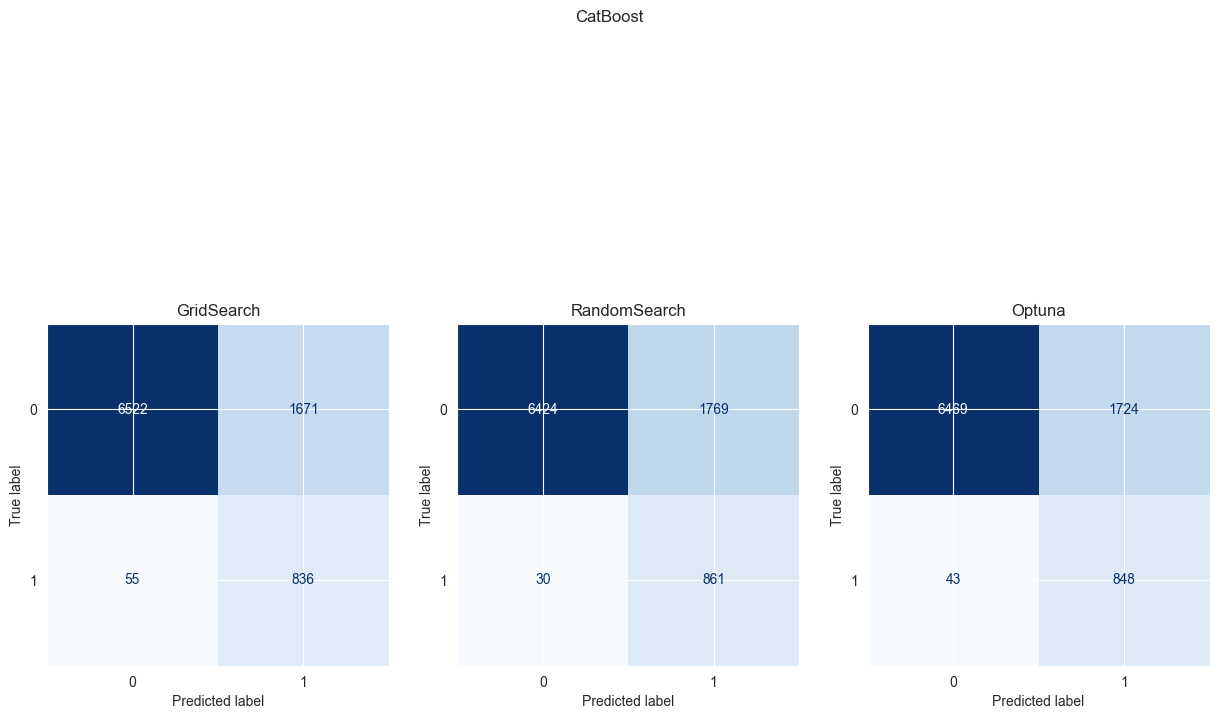

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15, 10))

for ax, (name_of_method, model_info) in zip(axes, cb_models["CatBoost"].items()):
    model = model_info["model"]
    predict = model.predict(X_test)
    name_of_model = f"CatBoost ({name_of_method})"

    input_into_table(X_train, X_test, y_train, y_test, model, name_of_model)

    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap=plt.cm.Blues, ax=ax, colorbar=False)


    ax.set_title(name_of_method)

plt.suptitle("CatBoost")

In [30]:
train_and_test_comparing

Train Data                             \
                                             F1 Accuracy Precision  Recall   
DecisionTreeRegressor (GridSearch)         0.64   0.8941    0.4781  0.9805   
DecisionTreeRegressor (RandomSearch)       0.61   0.8816    0.4490  0.9621   
DecisionTreeRegressor (Optuna)             0.47   0.7859    0.3103  0.9830   
Random Forest (GridSearch)                 0.62   0.8836    0.4545  0.9871   
Random Forest (RandomSearch)               0.62   0.8824    0.4520  0.9870   
Random Forest (Optuna)                     0.62   0.8828    0.4527  0.9871   
Bagging classifier                         0.43   0.8005    0.2968  0.7684   
Gradient Boosting (GridSearch)             0.53   0.8321    0.3652  0.9858   
Gradient Boosting (RandomSearch)           0.53   0.8327    0.3661  0.9858   
Gradient Boosting (Optuna)                 0.53   0.8312    0.3640  0.9850   
AdaBoost (GridSearch)                      0.47   0.7823    0.3075  0.9907   
AdaBoost (RandomSearch)                    0.47   0.7813    0.3067  0.9912   
AdaBoost (Optuna)                          0.47   0.7816    0.3069  0.9911   
Stacking classifier                        0.21   0.9125    0.8735  0.1164   
CatBoost (GridSearch)                      0.51   0.8195    0.3482  0.9834   
CatBoost (RandomSearch)                    0.49   0.8035    0.3291  0.9836   
CatBoost (Optuna)                          0.50   0.8116    0.3384  0.9829   

                                     Test Data                             
                                            F1 Accuracy Precision  Recall  
DecisionTreeRegressor (GridSearch)        0.50   0.8457    0.3656  0.7800  
DecisionTreeRegressor (RandomSearch)      0.50   0.8427    0.3619  0.7912  
DecisionTreeRegressor (Optuna)            0.48   0.7917    0.3187  0.9877  
Random Forest (GridSearch)                0.52   0.8427    0.3720  0.8777  
Random Forest (RandomSearch)              0.52   0.8437    0.3735  0.8765  
Random Forest (Optuna)                    0.52   0.8407    0.3687  0.8765  
Bagging classifier                        0.43   0.8028    0.3016  0.7677  
Gradient Boosting (GridSearch)            0.50   0.8163    0.3402  0.9293  
Gradient Boosting (RandomSearch)          0.50   0.8165    0.3412  0.9360  
Gradient Boosting (Optuna)                0.50   0.8172    0.3423  0.9383  
AdaBoost (GridSearch)                     0.48   0.7881    0.3155  0.9921  
AdaBoost (RandomSearch)                   0.48   0.7874    0.3149  0.9933  
AdaBoost (Optuna)                         0.48   0.7875    0.3151  0.9933  
Stacking classifier                       0.21   0.9116    0.8548  0.1190  
CatBoost (GridSearch)                     0.49   0.8100    0.3335  0.9383  
CatBoost (RandomSearch)                   0.49   0.8020    0.3274  0.9663  
CatBoost (Optuna)                         0.49   0.8055    0.3297  0.9517

Заметим, что CatBoost также показал хорошие результаты наравне с CatBoost - значение метрики Recall выше 0.95.

### XGBoost

In [33]:
xgb_config = {
    "XGBoost": {
        "model": XGBClassifier,
        "param_grid": {
            'n_estimators': [100, 200, 300, 400, 500],
            'learning_rate': [0.01, 0.05, 0.1],
            'max_depth': [4, 6, 8],
            'reg_lambda': [1, 3, 5, 7, 9],
            'tree_method': ['hist'],
        }
    }
}

In [34]:
xgb_models = train_models_with_cross_val(X_train, y_train, xgb_config)

Fitting 5 folds for each of 225 candidates, totalling 1125 fits
Fitting 5 folds for each of 10 candidates, totalling 50 fits


[I 2026-04-20 18:30:02,637] A new study created in memory with name: no-name-b99abc5e-1fb5-46bd-b98b-f0ced6980649
[I 2026-04-20 18:30:09,697] Trial 0 finished with value: 0.4814485410944947 and parameters: {'n_estimators': 500, 'learning_rate': 0.04333437160696576, 'max_depth': 8, 'reg_lambda': 7, 'tree_method': 'hist'}. Best is trial 0 with value: 0.4814485410944947.
[I 2026-04-20 18:30:15,042] Trial 1 finished with value: 0.48505447451148154 and parameters: {'n_estimators': 300, 'learning_rate': 0.09332775882479387, 'max_depth': 8, 'reg_lambda': 3, 'tree_method': 'hist'}. Best is trial 1 with value: 0.48505447451148154.
[I 2026-04-20 18:30:19,796] Trial 2 finished with value: 0.4812217554745649 and parameters: {'n_estimators': 300, 'learning_rate': 0.07715761084273, 'max_depth': 6, 'reg_lambda': 1, 'tree_method': 'hist'}. Best is trial 1 with value: 0.48505447451148154.
[I 2026-04-20 18:30:23,427] Trial 3 finished with value: 0.4772288431547903 and parameters: {'n_estimators': 100, '

Text(0.5, 0.98, 'XGBoost')

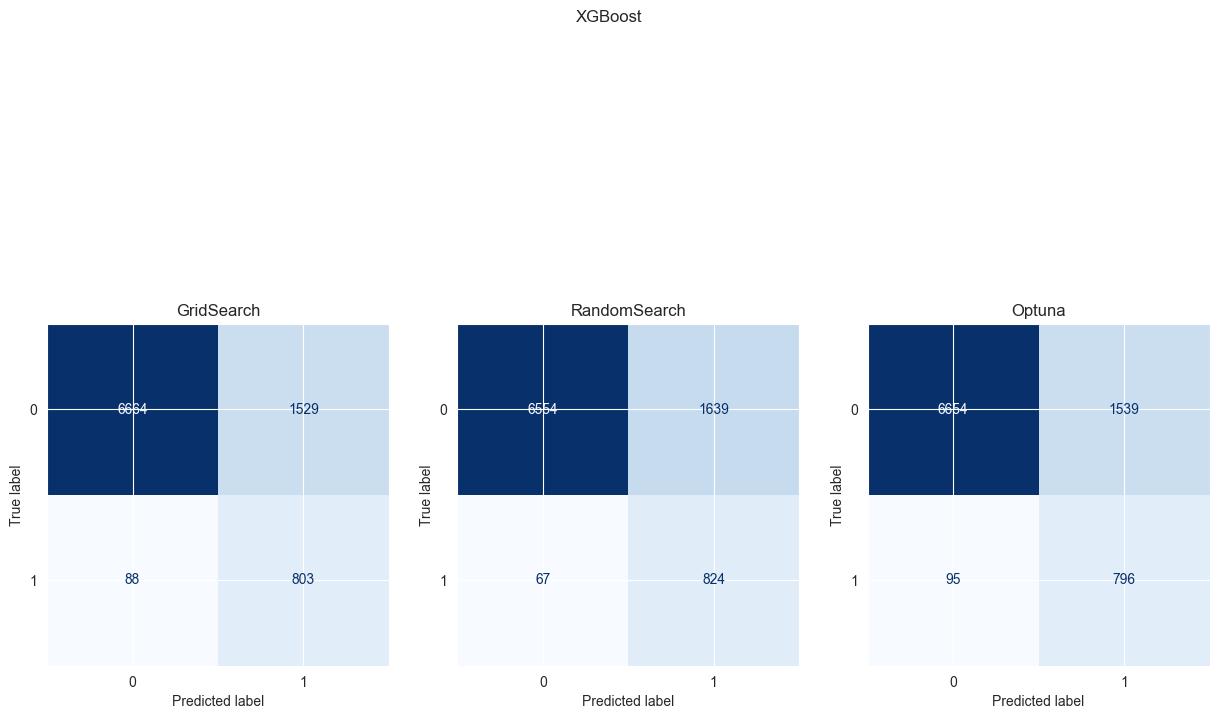

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(15, 10))

for ax, (name_of_method, model_info) in zip(axes, xgb_models["XGBoost"].items()):
    model = model_info["model"]
    predict = model.predict(X_test)
    name_of_model = f"XGBoost ({name_of_method})"

    input_into_table(X_train, X_test, y_train, y_test, model, name_of_model)

    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap=plt.cm.Blues, ax=ax, colorbar=False)


    ax.set_title(name_of_method)

plt.suptitle("XGBoost")

In [36]:
train_and_test_comparing

Train Data                             \
                                             F1 Accuracy Precision  Recall   
DecisionTreeRegressor (GridSearch)         0.64   0.8941    0.4781  0.9805   
DecisionTreeRegressor (RandomSearch)       0.61   0.8816    0.4490  0.9621   
DecisionTreeRegressor (Optuna)             0.47   0.7859    0.3103  0.9830   
Random Forest (GridSearch)                 0.62   0.8836    0.4545  0.9871   
Random Forest (RandomSearch)               0.62   0.8824    0.4520  0.9870   
Random Forest (Optuna)                     0.62   0.8828    0.4527  0.9871   
Bagging classifier                         0.43   0.8005    0.2968  0.7684   
Gradient Boosting (GridSearch)             0.53   0.8321    0.3652  0.9858   
Gradient Boosting (RandomSearch)           0.53   0.8327    0.3661  0.9858   
Gradient Boosting (Optuna)                 0.53   0.8312    0.3640  0.9850   
AdaBoost (GridSearch)                      0.47   0.7823    0.3075  0.9907   
AdaBoost (RandomSearch)                    0.47   0.7813    0.3067  0.9912   
AdaBoost (Optuna)                          0.47   0.7816    0.3069  0.9911   
Stacking classifier                        0.21   0.9125    0.8735  0.1164   
CatBoost (GridSearch)                      0.51   0.8195    0.3482  0.9834   
CatBoost (RandomSearch)                    0.49   0.8035    0.3291  0.9836   
CatBoost (Optuna)                          0.50   0.8116    0.3384  0.9829   
XGBoost (GridSearch)                       0.55   0.8437    0.3820  0.9841   
XGBoost (RandomSearch)                     0.53   0.8271    0.3583  0.9843   
XGBoost (Optuna)                           0.56   0.8468    0.3868  0.9850   

                                     Test Data                             
                                            F1 Accuracy Precision  Recall  
DecisionTreeRegressor (GridSearch)        0.50   0.8457    0.3656  0.7800  
DecisionTreeRegressor (RandomSearch)      0.50   0.8427    0.3619  0.7912  
DecisionTreeRegressor (Optuna)            0.48   0.7917    0.3187  0.9877  
Random Forest (GridSearch)                0.52   0.8427    0.3720  0.8777  
Random Forest (RandomSearch)              0.52   0.8437    0.3735  0.8765  
Random Forest (Optuna)                    0.52   0.8407    0.3687  0.8765  
Bagging classifier                        0.43   0.8028    0.3016  0.7677  
Gradient Boosting (GridSearch)            0.50   0.8163    0.3402  0.9293  
Gradient Boosting (RandomSearch)          0.50   0.8165    0.3412  0.9360  
Gradient Boosting (Optuna)                0.50   0.8172    0.3423  0.9383  
AdaBoost (GridSearch)                     0.48   0.7881    0.3155  0.9921  
AdaBoost (RandomSearch)                   0.48   0.7874    0.3149  0.9933  
AdaBoost (Optuna)                         0.48   0.7875    0.3151  0.9933  
Stacking classifier                       0.21   0.9116    0.8548  0.1190  
CatBoost (GridSearch)                     0.49   0.8100    0.3335  0.9383  
CatBoost (RandomSearch)                   0.49   0.8020    0.3274  0.9663  
CatBoost (Optuna)                         0.49   0.8055    0.3297  0.9517  
XGBoost (GridSearch)                      0.50   0.8220    0.3443  0.9012  
XGBoost (RandomSearch)                    0.49   0.8122    0.3346  0.9248  
XGBoost (Optuna)                          0.49   0.8201    0.3409  0.8934

Модель XGBoost показала результаты хуже, чем CatBoost и AdaBoost, но ее метрики все равно неплохие (Recall = 0.92, F1 = 0.49).

### LightGBM

In [39]:
lgbm_config = {
    "LightGBM": {
        "model": LGBMClassifier,
        "param_grid": {
            'n_estimators': [100, 200, 300, 400, 500],
            'learning_rate': [0.01, 0.05, 0.1],
            'max_depth': [4, 6, 8],
            'num_leaves': [15, 30],
        }
    }
}

In [40]:
lgbm_models = train_models_with_cross_val(X_train, y_train, lgbm_config)

Fitting 5 folds for each of 90 candidates, totalling 450 fits
[LightGBM] [Info] Number of positive: 59980, number of negative: 54461
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000784 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 114441, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.524113 -> initscore=0.096526
[LightGBM] [Info] Start training from score 0.096526
Fitting 5 folds for each of 10 candidates, totalling 50 fits
[LightGBM] [Info] Number of positive: 59980, number of negative: 54461
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000254 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train s

[I 2026-04-20 18:39:32,330] A new study created in memory with name: no-name-6293aa5a-b58a-41a8-8f1e-50b70774f953


[LightGBM] [Info] Number of positive: 47932, number of negative: 43519
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001086 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 91451, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.524128 -> initscore=0.096586
[LightGBM] [Info] Start training from score 0.096586
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

[I 2026-04-20 18:39:36,059] Trial 0 finished with value: 0.47527757192997855 and parameters: {'n_estimators': 100, 'learning_rate': 0.09931378349891325, 'max_depth': 4, 'num_leaves': 30}. Best is trial 0 with value: 0.47527757192997855.


[LightGBM] [Info] Number of positive: 47909, number of negative: 43503
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000336 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 91412, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.524100 -> initscore=0.096473
[LightGBM] [Info] Start training from score 0.096473
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

[I 2026-04-20 18:39:39,898] Trial 1 finished with value: 0.4756694258410773 and parameters: {'n_estimators': 200, 'learning_rate': 0.056342028691708096, 'max_depth': 4, 'num_leaves': 30}. Best is trial 1 with value: 0.4756694258410773.


[LightGBM] [Info] Number of positive: 47909, number of negative: 43503
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000744 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 91412, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.524100 -> initscore=0.096473
[LightGBM] [Info] Start training from score 0.096473
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

[I 2026-04-20 18:39:44,153] Trial 2 finished with value: 0.4770675728085968 and parameters: {'n_estimators': 300, 'learning_rate': 0.03437881841600457, 'max_depth': 8, 'num_leaves': 15}. Best is trial 2 with value: 0.4770675728085968.


[LightGBM] [Info] Number of positive: 47932, number of negative: 43519
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001076 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 91451, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.524128 -> initscore=0.096586
[LightGBM] [Info] Start training from score 0.096586
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

[I 2026-04-20 18:39:47,930] Trial 3 finished with value: 0.47528620706330643 and parameters: {'n_estimators': 200, 'learning_rate': 0.05821673277240958, 'max_depth': 4, 'num_leaves': 30}. Best is trial 2 with value: 0.4770675728085968.


[LightGBM] [Info] Number of positive: 47932, number of negative: 43519
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001076 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 91451, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.524128 -> initscore=0.096586
[LightGBM] [Info] Start training from score 0.096586
[LightGBM] [Info] Number of positive: 47898, number of negative: 43486
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001093 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 91384, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.524140 -> initscore=0.096635
[LightGBM] [Info] Start training from score 0.096635
[LightGBM] [Info] 

[I 2026-04-20 18:39:51,342] Trial 4 finished with value: 0.4783075400393632 and parameters: {'n_estimators': 100, 'learning_rate': 0.08268978570426665, 'max_depth': 8, 'num_leaves': 30}. Best is trial 4 with value: 0.4783075400393632.


[LightGBM] [Info] Number of positive: 47909, number of negative: 43503
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001153 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 91412, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.524100 -> initscore=0.096473
[LightGBM] [Info] Start training from score 0.096473
[LightGBM] [Info] Number of positive: 47932, number of negative: 43519
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000769 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 91451, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.524128 -> initscore=0.096586
[LightGBM] [Info] Start training from score 0.096586
[LightGBM] [Warnin

[I 2026-04-20 18:39:55,167] Trial 5 finished with value: 0.47327969578559853 and parameters: {'n_estimators': 200, 'learning_rate': 0.022966862335937352, 'max_depth': 4, 'num_leaves': 30}. Best is trial 4 with value: 0.4783075400393632.


[LightGBM] [Info] Number of positive: 47909, number of negative: 43503
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001201 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 91412, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.524100 -> initscore=0.096473
[LightGBM] [Info] Start training from score 0.096473
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

[I 2026-04-20 18:39:58,671] Trial 6 finished with value: 0.4758115517866166 and parameters: {'n_estimators': 100, 'learning_rate': 0.05450275065681678, 'max_depth': 6, 'num_leaves': 15}. Best is trial 4 with value: 0.4783075400393632.


[LightGBM] [Info] Number of positive: 47909, number of negative: 43503
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001113 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 91412, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.524100 -> initscore=0.096473
[LightGBM] [Info] Start training from score 0.096473
[LightGBM] [Info] Number of positive: 47932, number of negative: 43519
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000897 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 91451, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.524128 -> initscore=0.096586
[LightGBM] [Info] Start training from score 0.096586
[LightGBM] [Info] 

[I 2026-04-20 18:40:02,780] Trial 7 finished with value: 0.47804421348645476 and parameters: {'n_estimators': 200, 'learning_rate': 0.0810707539771479, 'max_depth': 8, 'num_leaves': 15}. Best is trial 4 with value: 0.4783075400393632.


[LightGBM] [Info] Number of positive: 47932, number of negative: 43519
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001002 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 91451, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.524128 -> initscore=0.096586
[LightGBM] [Info] Start training from score 0.096586
[LightGBM] [Info] Number of positive: 47898, number of negative: 43486
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001046 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 91384, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.524140 -> initscore=0.096635
[LightGBM] [Info] Start training from score 0.096635
[LightGBM] [Info] 

[I 2026-04-20 18:40:06,860] Trial 8 finished with value: 0.47488238493080226 and parameters: {'n_estimators': 200, 'learning_rate': 0.011116117897459173, 'max_depth': 6, 'num_leaves': 15}. Best is trial 4 with value: 0.4783075400393632.


[LightGBM] [Info] Number of positive: 47932, number of negative: 43519
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001116 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 91451, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.524128 -> initscore=0.096586
[LightGBM] [Info] Start training from score 0.096586
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

[I 2026-04-20 18:40:11,017] Trial 9 finished with value: 0.4746232040748571 and parameters: {'n_estimators': 200, 'learning_rate': 0.04702272986200997, 'max_depth': 4, 'num_leaves': 15}. Best is trial 4 with value: 0.4783075400393632.


[LightGBM] [Info] Number of positive: 47909, number of negative: 43503
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001111 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 91412, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.524100 -> initscore=0.096473
[LightGBM] [Info] Start training from score 0.096473
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

[I 2026-04-20 18:40:17,422] Trial 10 finished with value: 0.48238685420312566 and parameters: {'n_estimators': 400, 'learning_rate': 0.07886327372737022, 'max_depth': 8, 'num_leaves': 30}. Best is trial 10 with value: 0.48238685420312566.


[LightGBM] [Info] Number of positive: 47932, number of negative: 43519
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001087 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 91451, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.524128 -> initscore=0.096586
[LightGBM] [Info] Start training from score 0.096586
[LightGBM] [Info] Number of positive: 47898, number of negative: 43486
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001019 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 91384, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.524140 -> initscore=0.096635
[LightGBM] [Info] Start training from score 0.096635
[LightGBM] [Info] 

[I 2026-04-20 18:40:22,802] Trial 11 finished with value: 0.4843825605820511 and parameters: {'n_estimators': 400, 'learning_rate': 0.07927179614968287, 'max_depth': 8, 'num_leaves': 30}. Best is trial 11 with value: 0.4843825605820511.


[LightGBM] [Info] Number of positive: 47932, number of negative: 43519
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001089 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 91451, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.524128 -> initscore=0.096586
[LightGBM] [Info] Start training from score 0.096586
[LightGBM] [Info] Number of positive: 47898, number of negative: 43486
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000979 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 91384, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.524140 -> initscore=0.096635
[LightGBM] [Info] Start training from score 0.096635
[LightGBM] [Info] 

[I 2026-04-20 18:40:28,265] Trial 12 finished with value: 0.48202777896090054 and parameters: {'n_estimators': 400, 'learning_rate': 0.07648744486412443, 'max_depth': 8, 'num_leaves': 30}. Best is trial 11 with value: 0.4843825605820511.


[LightGBM] [Info] Number of positive: 47932, number of negative: 43519
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001337 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 91451, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.524128 -> initscore=0.096586
[LightGBM] [Info] Start training from score 0.096586
[LightGBM] [Info] Number of positive: 47898, number of negative: 43486
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000977 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 91384, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.524140 -> initscore=0.096635
[LightGBM] [Info] Start training from score 0.096635
[LightGBM] [Info] 

[I 2026-04-20 18:40:33,570] Trial 13 finished with value: 0.48329734937664776 and parameters: {'n_estimators': 400, 'learning_rate': 0.09807054737945445, 'max_depth': 8, 'num_leaves': 30}. Best is trial 11 with value: 0.4843825605820511.


[LightGBM] [Info] Number of positive: 47932, number of negative: 43519
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000984 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 91451, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.524128 -> initscore=0.096586
[LightGBM] [Info] Start training from score 0.096586
[LightGBM] [Info] Number of positive: 47898, number of negative: 43486
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001022 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 91384, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.524140 -> initscore=0.096635
[LightGBM] [Info] Start training from score 0.096635
[LightGBM] [Info] 

[I 2026-04-20 18:40:39,856] Trial 14 finished with value: 0.48555487367102457 and parameters: {'n_estimators': 500, 'learning_rate': 0.09867049197582141, 'max_depth': 8, 'num_leaves': 30}. Best is trial 14 with value: 0.48555487367102457.


[LightGBM] [Info] Number of positive: 59980, number of negative: 54461
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001290 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 114441, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.524113 -> initscore=0.096526
[LightGBM] [Info] Start training from score 0.096526


Text(0.5, 0.98, 'LightGBM')

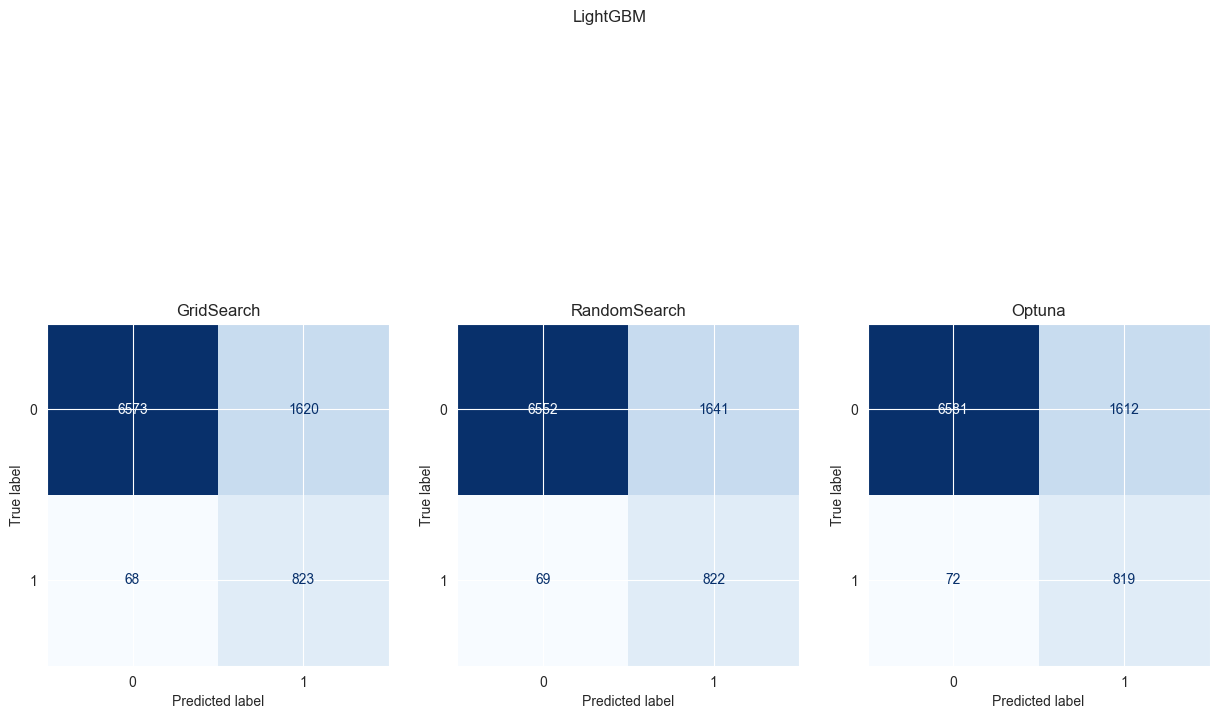

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(15, 10))

for ax, (name_of_method, model_info) in zip(axes, lgbm_models["LightGBM"].items()):
    model = model_info["model"]
    predict = model.predict(X_test)
    name_of_model = f"LightGBM ({name_of_method})"

    input_into_table(X_train, X_test, y_train, y_test, model, name_of_model)

    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap=plt.cm.Blues, ax=ax, colorbar=False)


    ax.set_title(name_of_method)

plt.suptitle("LightGBM")

In [42]:
train_and_test_comparing

Train Data                             \
                                             F1 Accuracy Precision  Recall   
DecisionTreeRegressor (GridSearch)         0.64   0.8941    0.4781  0.9805   
DecisionTreeRegressor (RandomSearch)       0.61   0.8816    0.4490  0.9621   
DecisionTreeRegressor (Optuna)             0.47   0.7859    0.3103  0.9830   
Random Forest (GridSearch)                 0.62   0.8836    0.4545  0.9871   
Random Forest (RandomSearch)               0.62   0.8824    0.4520  0.9870   
Random Forest (Optuna)                     0.62   0.8828    0.4527  0.9871   
Bagging classifier                         0.43   0.8005    0.2968  0.7684   
Gradient Boosting (GridSearch)             0.53   0.8321    0.3652  0.9858   
Gradient Boosting (RandomSearch)           0.53   0.8327    0.3661  0.9858   
Gradient Boosting (Optuna)                 0.53   0.8312    0.3640  0.9850   
AdaBoost (GridSearch)                      0.47   0.7823    0.3075  0.9907   
AdaBoost (RandomSearch)                    0.47   0.7813    0.3067  0.9912   
AdaBoost (Optuna)                          0.47   0.7816    0.3069  0.9911   
Stacking classifier                        0.21   0.9125    0.8735  0.1164   
CatBoost (GridSearch)                      0.51   0.8195    0.3482  0.9834   
CatBoost (RandomSearch)                    0.49   0.8035    0.3291  0.9836   
CatBoost (Optuna)                          0.50   0.8116    0.3384  0.9829   
XGBoost (GridSearch)                       0.55   0.8437    0.3820  0.9841   
XGBoost (RandomSearch)                     0.53   0.8271    0.3583  0.9843   
XGBoost (Optuna)                           0.56   0.8468    0.3868  0.9850   
LightGBM (GridSearch)                      0.53   0.8318    0.3648  0.9864   
LightGBM (RandomSearch)                    0.52   0.8254    0.3561  0.9851   
LightGBM (Optuna)                          0.53   0.8314    0.3644  0.9871   

                                     Test Data                             
                                            F1 Accuracy Precision  Recall  
DecisionTreeRegressor (GridSearch)        0.50   0.8457    0.3656  0.7800  
DecisionTreeRegressor (RandomSearch)      0.50   0.8427    0.3619  0.7912  
DecisionTreeRegressor (Optuna)            0.48   0.7917    0.3187  0.9877  
Random Forest (GridSearch)                0.52   0.8427    0.3720  0.8777  
Random Forest (RandomSearch)              0.52   0.8437    0.3735  0.8765  
Random Forest (Optuna)                    0.52   0.8407    0.3687  0.8765  
Bagging classifier                        0.43   0.8028    0.3016  0.7677  
Gradient Boosting (GridSearch)            0.50   0.8163    0.3402  0.9293  
Gradient Boosting (RandomSearch)          0.50   0.8165    0.3412  0.9360  
Gradient Boosting (Optuna)                0.50   0.8172    0.3423  0.9383  
AdaBoost (GridSearch)                     0.48   0.7881    0.3155  0.9921  
AdaBoost (RandomSearch)                   0.48   0.7874    0.3149  0.9933  
AdaBoost (Optuna)                         0.48   0.7875    0.3151  0.9933  
Stacking classifier                       0.21   0.9116    0.8548  0.1190  
CatBoost (GridSearch)                     0.49   0.8100    0.3335  0.9383  
CatBoost (RandomSearch)                   0.49   0.8020    0.3274  0.9663  
CatBoost (Optuna)                         0.49   0.8055    0.3297  0.9517  
XGBoost (GridSearch)                      0.50   0.8220    0.3443  0.9012  
XGBoost (RandomSearch)                    0.49   0.8122    0.3346  0.9248  
XGBoost (Optuna)                          0.49   0.8201    0.3409  0.8934  
LightGBM (GridSearch)                     0.49   0.8142    0.3369  0.9237  
LightGBM (RandomSearch)                   0.49   0.8118    0.3337  0.9226  
LightGBM (Optuna)                         0.49   0.8146    0.3369  0.9192

LightGBM тоже показала неплохие результаты (F1 = 0.49, Recall выше 0.9), хотя и чуть хуже, чем AdaBoost и CatBoost.

### SketchBoost

In [45]:
from py_boost import SketchBoost
from sklearn.model_selection import KFold

def objective(trial):
    params = {
        'loss': 'logloss',
        'lr': trial.suggest_float('lr', 0.005, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'ntrees': trial.suggest_int('ntrees', 100, 1000, step=50),
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-3, 1.0, log=True)
    }


    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = []

    for train_idx, val_idx in kf.split(X_train):
        X_t, X_v = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_t, y_v = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = SketchBoost(**params)
        model.fit(X_t, y_t)
        preds_prob = model.predict(X_v)
        preds_class = (preds_prob > 0.5).astype(int)
        cv_scores.append(f1_score(y_v, preds_class))

    return np.mean(cv_scores)


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

final_sb_model = SketchBoost(loss='l2', **study.best_params)
final_sb_model.fit(X_train, y_train)

[I 2026-04-20 18:45:17,901] A new study created in memory with name: no-name-46410ca9-f533-425f-a5dd-fdc4eb0d1f6d


[18:45:17] Stdout logging level is INFO.
[18:45:17] GDBT train starts. Max iter 550, early stopping rounds 100
[18:45:17] Iter 0; 
[18:45:18] Iter 10; 
[18:45:18] Iter 20; 
[18:45:18] Iter 30; 
[18:45:18] Iter 40; 
[18:45:18] Iter 50; 
[18:45:19] Iter 60; 
[18:45:19] Iter 70; 
[18:45:19] Iter 80; 
[18:45:19] Iter 90; 
[18:45:19] Iter 100; 
[18:45:19] Iter 110; 
[18:45:20] Iter 120; 
[18:45:20] Iter 130; 
[18:45:20] Iter 140; 
[18:45:20] Iter 150; 
[18:45:20] Iter 160; 
[18:45:21] Iter 170; 
[18:45:21] Iter 180; 
[18:45:21] Iter 190; 
[18:45:21] Iter 200; 
[18:45:21] Iter 210; 
[18:45:22] Iter 220; 
[18:45:22] Iter 230; 
[18:45:22] Iter 240; 
[18:45:22] Iter 250; 
[18:45:22] Iter 260; 
[18:45:22] Iter 270; 
[18:45:23] Iter 280; 
[18:45:23] Iter 290; 
[18:45:23] Iter 300; 
[18:45:23] Iter 310; 
[18:45:23] Iter 320; 
[18:45:24] Iter 330; 
[18:45:24] Iter 340; 
[18:45:24] Iter 350; 
[18:45:24] Iter 360; 
[18:45:25] Iter 370; 
[18:45:25] Iter 380; 
[18:45:25] Iter 390; 
[18:45:25] Iter 400;

[I 2026-04-20 18:46:13,287] Trial 0 finished with value: 0.43038687353747174 and parameters: {'lr': 0.12023339015064671, 'max_depth': 9, 'ntrees': 550, 'lambda_l2': 0.0011079556049893799}. Best is trial 0 with value: 0.43038687353747174.


[18:46:13] Stdout logging level is INFO.
[18:46:13] GDBT train starts. Max iter 500, early stopping rounds 100
[18:46:13] Iter 0; 
[18:46:13] Iter 10; 
[18:46:13] Iter 20; 
[18:46:13] Iter 30; 
[18:46:14] Iter 40; 
[18:46:14] Iter 50; 
[18:46:14] Iter 60; 
[18:46:14] Iter 70; 
[18:46:14] Iter 80; 
[18:46:15] Iter 90; 
[18:46:15] Iter 100; 
[18:46:15] Iter 110; 
[18:46:15] Iter 120; 
[18:46:16] Iter 130; 
[18:46:16] Iter 140; 
[18:46:16] Iter 150; 
[18:46:16] Iter 160; 
[18:46:16] Iter 170; 
[18:46:17] Iter 180; 
[18:46:17] Iter 190; 
[18:46:17] Iter 200; 
[18:46:17] Iter 210; 
[18:46:17] Iter 220; 
[18:46:18] Iter 230; 
[18:46:18] Iter 240; 
[18:46:18] Iter 250; 
[18:46:18] Iter 260; 
[18:46:18] Iter 270; 
[18:46:19] Iter 280; 
[18:46:19] Iter 290; 
[18:46:19] Iter 300; 
[18:46:19] Iter 310; 
[18:46:19] Iter 320; 
[18:46:20] Iter 330; 
[18:46:20] Iter 340; 
[18:46:20] Iter 350; 
[18:46:20] Iter 360; 
[18:46:21] Iter 370; 
[18:46:21] Iter 380; 
[18:46:21] Iter 390; 
[18:46:21] Iter 400;

[I 2026-04-20 18:47:05,438] Trial 1 finished with value: 0.4304741938740717 and parameters: {'lr': 0.13130200628679453, 'max_depth': 9, 'ntrees': 500, 'lambda_l2': 0.1385212572986702}. Best is trial 1 with value: 0.4304741938740717.


[18:47:05] Stdout logging level is INFO.
[18:47:05] GDBT train starts. Max iter 400, early stopping rounds 100
[18:47:05] Iter 0; 
[18:47:05] Iter 10; 
[18:47:05] Iter 20; 
[18:47:06] Iter 30; 
[18:47:06] Iter 40; 
[18:47:06] Iter 50; 
[18:47:06] Iter 60; 
[18:47:06] Iter 70; 
[18:47:06] Iter 80; 
[18:47:07] Iter 90; 
[18:47:07] Iter 100; 
[18:47:07] Iter 110; 
[18:47:07] Iter 120; 
[18:47:07] Iter 130; 
[18:47:07] Iter 140; 
[18:47:08] Iter 150; 
[18:47:08] Iter 160; 
[18:47:08] Iter 170; 
[18:47:08] Iter 180; 
[18:47:08] Iter 190; 
[18:47:09] Iter 200; 
[18:47:09] Iter 210; 
[18:47:09] Iter 220; 
[18:47:09] Iter 230; 
[18:47:09] Iter 240; 
[18:47:09] Iter 250; 
[18:47:10] Iter 260; 
[18:47:10] Iter 270; 
[18:47:10] Iter 280; 
[18:47:10] Iter 290; 
[18:47:10] Iter 300; 
[18:47:10] Iter 310; 
[18:47:11] Iter 320; 
[18:47:11] Iter 330; 
[18:47:11] Iter 340; 
[18:47:11] Iter 350; 
[18:47:11] Iter 360; 
[18:47:12] Iter 370; 
[18:47:12] Iter 380; 
[18:47:12] Iter 390; 
[18:47:12] Iter 399;

[I 2026-04-20 18:47:41,616] Trial 2 finished with value: 0.32566153138013854 and parameters: {'lr': 0.029695819980189636, 'max_depth': 8, 'ntrees': 400, 'lambda_l2': 0.0010944928092474794}. Best is trial 1 with value: 0.4304741938740717.


[18:47:41] Stdout logging level is INFO.
[18:47:41] GDBT train starts. Max iter 600, early stopping rounds 100
[18:47:41] Iter 0; 
[18:47:41] Iter 10; 
[18:47:41] Iter 20; 
[18:47:41] Iter 30; 
[18:47:42] Iter 40; 
[18:47:42] Iter 50; 
[18:47:42] Iter 60; 
[18:47:42] Iter 70; 
[18:47:42] Iter 80; 
[18:47:42] Iter 90; 
[18:47:42] Iter 100; 
[18:47:42] Iter 110; 
[18:47:42] Iter 120; 
[18:47:42] Iter 130; 
[18:47:42] Iter 140; 
[18:47:43] Iter 150; 
[18:47:43] Iter 160; 
[18:47:43] Iter 170; 
[18:47:43] Iter 180; 
[18:47:43] Iter 190; 
[18:47:43] Iter 200; 
[18:47:43] Iter 210; 
[18:47:43] Iter 220; 
[18:47:43] Iter 230; 
[18:47:43] Iter 240; 
[18:47:43] Iter 250; 
[18:47:44] Iter 260; 
[18:47:44] Iter 270; 
[18:47:44] Iter 280; 
[18:47:44] Iter 290; 
[18:47:44] Iter 300; 
[18:47:44] Iter 310; 
[18:47:44] Iter 320; 
[18:47:44] Iter 330; 
[18:47:44] Iter 340; 
[18:47:44] Iter 350; 
[18:47:44] Iter 360; 
[18:47:45] Iter 370; 
[18:47:45] Iter 380; 
[18:47:45] Iter 390; 
[18:47:45] Iter 400;

[I 2026-04-20 18:48:09,397] Trial 3 finished with value: 0.31936686384837015 and parameters: {'lr': 0.05679218832053884, 'max_depth': 4, 'ntrees': 600, 'lambda_l2': 0.04607259271070337}. Best is trial 1 with value: 0.4304741938740717.


[18:48:09] Stdout logging level is INFO.
[18:48:09] GDBT train starts. Max iter 550, early stopping rounds 100
[18:48:09] Iter 0; 
[18:48:09] Iter 10; 
[18:48:09] Iter 20; 
[18:48:09] Iter 30; 
[18:48:10] Iter 40; 
[18:48:10] Iter 50; 
[18:48:10] Iter 60; 
[18:48:10] Iter 70; 
[18:48:10] Iter 80; 
[18:48:10] Iter 90; 
[18:48:11] Iter 100; 
[18:48:11] Iter 110; 
[18:48:11] Iter 120; 
[18:48:11] Iter 130; 
[18:48:11] Iter 140; 
[18:48:11] Iter 150; 
[18:48:11] Iter 160; 
[18:48:12] Iter 170; 
[18:48:12] Iter 180; 
[18:48:12] Iter 190; 
[18:48:12] Iter 200; 
[18:48:12] Iter 210; 
[18:48:12] Iter 220; 
[18:48:13] Iter 230; 
[18:48:13] Iter 240; 
[18:48:13] Iter 250; 
[18:48:13] Iter 260; 
[18:48:13] Iter 270; 
[18:48:13] Iter 280; 
[18:48:14] Iter 290; 
[18:48:14] Iter 300; 
[18:48:14] Iter 310; 
[18:48:14] Iter 320; 
[18:48:14] Iter 330; 
[18:48:14] Iter 340; 
[18:48:15] Iter 350; 
[18:48:15] Iter 360; 
[18:48:15] Iter 370; 
[18:48:15] Iter 380; 
[18:48:15] Iter 390; 
[18:48:15] Iter 400;

[I 2026-04-20 18:48:54,087] Trial 4 finished with value: 0.37132149025034344 and parameters: {'lr': 0.049533956512640046, 'max_depth': 7, 'ntrees': 550, 'lambda_l2': 0.18906170948027567}. Best is trial 1 with value: 0.4304741938740717.


[18:48:54] Stdout logging level is INFO.
[18:48:54] GDBT train starts. Max iter 700, early stopping rounds 100
[18:48:54] Iter 0; 
[18:48:54] Iter 10; 
[18:48:54] Iter 20; 
[18:48:54] Iter 30; 
[18:48:54] Iter 40; 
[18:48:55] Iter 50; 
[18:48:55] Iter 60; 
[18:48:55] Iter 70; 
[18:48:55] Iter 80; 
[18:48:55] Iter 90; 
[18:48:56] Iter 100; 
[18:48:56] Iter 110; 
[18:48:56] Iter 120; 
[18:48:56] Iter 130; 
[18:48:56] Iter 140; 
[18:48:57] Iter 150; 
[18:48:57] Iter 160; 
[18:48:57] Iter 170; 
[18:48:57] Iter 180; 
[18:48:57] Iter 190; 
[18:48:58] Iter 200; 
[18:48:58] Iter 210; 
[18:48:58] Iter 220; 
[18:48:58] Iter 230; 
[18:48:59] Iter 240; 
[18:48:59] Iter 250; 
[18:48:59] Iter 260; 
[18:48:59] Iter 270; 
[18:48:59] Iter 280; 
[18:49:00] Iter 290; 
[18:49:00] Iter 300; 
[18:49:00] Iter 310; 
[18:49:00] Iter 320; 
[18:49:00] Iter 330; 
[18:49:01] Iter 340; 
[18:49:01] Iter 350; 
[18:49:01] Iter 360; 
[18:49:01] Iter 370; 
[18:49:01] Iter 380; 
[18:49:02] Iter 390; 
[18:49:02] Iter 400;

[I 2026-04-20 18:50:07,347] Trial 5 finished with value: 0.417063575780886 and parameters: {'lr': 0.05796387151398205, 'max_depth': 9, 'ntrees': 700, 'lambda_l2': 0.01847897146916243}. Best is trial 1 with value: 0.4304741938740717.


[18:50:07] Stdout logging level is INFO.
[18:50:07] GDBT train starts. Max iter 550, early stopping rounds 100
[18:50:07] Iter 0; 
[18:50:07] Iter 10; 
[18:50:07] Iter 20; 
[18:50:07] Iter 30; 
[18:50:07] Iter 40; 
[18:50:07] Iter 50; 
[18:50:07] Iter 60; 
[18:50:08] Iter 70; 
[18:50:08] Iter 80; 
[18:50:08] Iter 90; 
[18:50:08] Iter 100; 
[18:50:08] Iter 110; 
[18:50:08] Iter 120; 
[18:50:08] Iter 130; 
[18:50:08] Iter 140; 
[18:50:08] Iter 150; 
[18:50:08] Iter 160; 
[18:50:08] Iter 170; 
[18:50:08] Iter 180; 
[18:50:09] Iter 190; 
[18:50:09] Iter 200; 
[18:50:09] Iter 210; 
[18:50:09] Iter 220; 
[18:50:09] Iter 230; 
[18:50:09] Iter 240; 
[18:50:09] Iter 250; 
[18:50:09] Iter 260; 
[18:50:09] Iter 270; 
[18:50:09] Iter 280; 
[18:50:09] Iter 290; 
[18:50:09] Iter 300; 
[18:50:10] Iter 310; 
[18:50:10] Iter 320; 
[18:50:10] Iter 330; 
[18:50:10] Iter 340; 
[18:50:10] Iter 350; 
[18:50:10] Iter 360; 
[18:50:10] Iter 370; 
[18:50:10] Iter 380; 
[18:50:10] Iter 390; 
[18:50:10] Iter 400;

[I 2026-04-20 18:50:32,551] Trial 6 finished with value: 0.2332816349503976 and parameters: {'lr': 0.010117662114050387, 'max_depth': 4, 'ntrees': 550, 'lambda_l2': 0.007021173584884091}. Best is trial 1 with value: 0.4304741938740717.


[18:50:32] Stdout logging level is INFO.
[18:50:32] GDBT train starts. Max iter 900, early stopping rounds 100
[18:50:32] Iter 0; 
[18:50:32] Iter 10; 
[18:50:32] Iter 20; 
[18:50:32] Iter 30; 
[18:50:32] Iter 40; 
[18:50:33] Iter 50; 
[18:50:33] Iter 60; 
[18:50:33] Iter 70; 
[18:50:33] Iter 80; 
[18:50:33] Iter 90; 
[18:50:33] Iter 100; 
[18:50:33] Iter 110; 
[18:50:33] Iter 120; 
[18:50:33] Iter 130; 
[18:50:33] Iter 140; 
[18:50:33] Iter 150; 
[18:50:34] Iter 160; 
[18:50:34] Iter 170; 
[18:50:34] Iter 180; 
[18:50:34] Iter 190; 
[18:50:34] Iter 200; 
[18:50:34] Iter 210; 
[18:50:34] Iter 220; 
[18:50:34] Iter 230; 
[18:50:34] Iter 240; 
[18:50:34] Iter 250; 
[18:50:34] Iter 260; 
[18:50:35] Iter 270; 
[18:50:35] Iter 280; 
[18:50:35] Iter 290; 
[18:50:35] Iter 300; 
[18:50:35] Iter 310; 
[18:50:35] Iter 320; 
[18:50:35] Iter 330; 
[18:50:35] Iter 340; 
[18:50:35] Iter 350; 
[18:50:35] Iter 360; 
[18:50:35] Iter 370; 
[18:50:36] Iter 380; 
[18:50:36] Iter 390; 
[18:50:36] Iter 400;

[I 2026-04-20 18:51:14,156] Trial 7 finished with value: 0.32672260784072227 and parameters: {'lr': 0.047210202937857874, 'max_depth': 4, 'ntrees': 900, 'lambda_l2': 0.9690614869767393}. Best is trial 1 with value: 0.4304741938740717.


[18:51:14] Stdout logging level is INFO.
[18:51:14] GDBT train starts. Max iter 650, early stopping rounds 100
[18:51:14] Iter 0; 
[18:51:14] Iter 10; 
[18:51:14] Iter 20; 
[18:51:14] Iter 30; 
[18:51:14] Iter 40; 
[18:51:14] Iter 50; 
[18:51:15] Iter 60; 
[18:51:15] Iter 70; 
[18:51:15] Iter 80; 
[18:51:15] Iter 90; 
[18:51:15] Iter 100; 
[18:51:15] Iter 110; 
[18:51:15] Iter 120; 
[18:51:16] Iter 130; 
[18:51:16] Iter 140; 
[18:51:16] Iter 150; 
[18:51:16] Iter 160; 
[18:51:16] Iter 170; 
[18:51:16] Iter 180; 
[18:51:17] Iter 190; 
[18:51:17] Iter 200; 
[18:51:17] Iter 210; 
[18:51:17] Iter 220; 
[18:51:17] Iter 230; 
[18:51:17] Iter 240; 
[18:51:17] Iter 250; 
[18:51:18] Iter 260; 
[18:51:18] Iter 270; 
[18:51:18] Iter 280; 
[18:51:18] Iter 290; 
[18:51:18] Iter 300; 
[18:51:18] Iter 310; 
[18:51:18] Iter 320; 
[18:51:19] Iter 330; 
[18:51:19] Iter 340; 
[18:51:19] Iter 350; 
[18:51:19] Iter 360; 
[18:51:19] Iter 370; 
[18:51:19] Iter 380; 
[18:51:20] Iter 390; 
[18:51:20] Iter 400;

[I 2026-04-20 18:52:06,600] Trial 8 finished with value: 0.40372280233808117 and parameters: {'lr': 0.0789649180313428, 'max_depth': 7, 'ntrees': 650, 'lambda_l2': 0.06823368252004014}. Best is trial 1 with value: 0.4304741938740717.


[18:52:06] Stdout logging level is INFO.
[18:52:06] GDBT train starts. Max iter 850, early stopping rounds 100
[18:52:06] Iter 0; 
[18:52:06] Iter 10; 
[18:52:06] Iter 20; 
[18:52:07] Iter 30; 
[18:52:07] Iter 40; 
[18:52:07] Iter 50; 
[18:52:07] Iter 60; 
[18:52:07] Iter 70; 
[18:52:07] Iter 80; 
[18:52:07] Iter 90; 
[18:52:07] Iter 100; 
[18:52:08] Iter 110; 
[18:52:08] Iter 120; 
[18:52:08] Iter 130; 
[18:52:08] Iter 140; 
[18:52:08] Iter 150; 
[18:52:08] Iter 160; 
[18:52:08] Iter 170; 
[18:52:08] Iter 180; 
[18:52:09] Iter 190; 
[18:52:09] Iter 200; 
[18:52:09] Iter 210; 
[18:52:09] Iter 220; 
[18:52:09] Iter 230; 
[18:52:09] Iter 240; 
[18:52:09] Iter 250; 
[18:52:10] Iter 260; 
[18:52:10] Iter 270; 
[18:52:10] Iter 280; 
[18:52:10] Iter 290; 
[18:52:10] Iter 300; 
[18:52:10] Iter 310; 
[18:52:10] Iter 320; 
[18:52:10] Iter 330; 
[18:52:11] Iter 340; 
[18:52:11] Iter 350; 
[18:52:11] Iter 360; 
[18:52:11] Iter 370; 
[18:52:11] Iter 380; 
[18:52:11] Iter 390; 
[18:52:11] Iter 400;

[I 2026-04-20 18:53:04,995] Trial 9 finished with value: 0.3851936698247902 and parameters: {'lr': 0.05764778670464201, 'max_depth': 6, 'ntrees': 850, 'lambda_l2': 0.0580757019670693}. Best is trial 1 with value: 0.4304741938740717.


[18:53:05] Stdout logging level is INFO.
[18:53:05] GDBT train starts. Max iter 100, early stopping rounds 100
[18:53:05] Iter 0; 
[18:53:05] Iter 10; 
[18:53:05] Iter 20; 
[18:53:05] Iter 30; 
[18:53:05] Iter 40; 
[18:53:06] Iter 50; 
[18:53:06] Iter 60; 
[18:53:06] Iter 70; 
[18:53:06] Iter 80; 
[18:53:07] Iter 90; 
[18:53:07] Iter 99; 
[18:53:07] Stdout logging level is INFO.
[18:53:07] GDBT train starts. Max iter 100, early stopping rounds 100
[18:53:07] Iter 0; 
[18:53:07] Iter 10; 
[18:53:07] Iter 20; 
[18:53:08] Iter 30; 
[18:53:08] Iter 40; 
[18:53:08] Iter 50; 
[18:53:08] Iter 60; 
[18:53:08] Iter 70; 
[18:53:09] Iter 80; 
[18:53:09] Iter 90; 
[18:53:09] Iter 99; 
[18:53:09] Stdout logging level is INFO.
[18:53:09] GDBT train starts. Max iter 100, early stopping rounds 100
[18:53:09] Iter 0; 
[18:53:09] Iter 10; 
[18:53:10] Iter 20; 
[18:53:10] Iter 30; 
[18:53:10] Iter 40; 
[18:53:10] Iter 50; 
[18:53:11] Iter 60; 
[18:53:11] Iter 70; 
[18:53:11] Iter 80; 
[18:53:11] Iter 90;

[I 2026-04-20 18:53:16,757] Trial 10 finished with value: 0.3945903542363481 and parameters: {'lr': 0.18071039613128692, 'max_depth': 10, 'ntrees': 100, 'lambda_l2': 0.4780137574800009}. Best is trial 1 with value: 0.4304741938740717.


[18:53:16] Stdout logging level is INFO.
[18:53:16] GDBT train starts. Max iter 350, early stopping rounds 100
[18:53:16] Iter 0; 
[18:53:17] Iter 10; 
[18:53:17] Iter 20; 
[18:53:17] Iter 30; 
[18:53:17] Iter 40; 
[18:53:18] Iter 50; 
[18:53:18] Iter 60; 
[18:53:18] Iter 70; 
[18:53:18] Iter 80; 
[18:53:19] Iter 90; 
[18:53:19] Iter 100; 
[18:53:19] Iter 110; 
[18:53:19] Iter 120; 
[18:53:19] Iter 130; 
[18:53:20] Iter 140; 
[18:53:20] Iter 150; 
[18:53:20] Iter 160; 
[18:53:20] Iter 170; 
[18:53:21] Iter 180; 
[18:53:21] Iter 190; 
[18:53:21] Iter 200; 
[18:53:21] Iter 210; 
[18:53:22] Iter 220; 
[18:53:22] Iter 230; 
[18:53:22] Iter 240; 
[18:53:22] Iter 250; 
[18:53:22] Iter 260; 
[18:53:23] Iter 270; 
[18:53:23] Iter 280; 
[18:53:23] Iter 290; 
[18:53:23] Iter 300; 
[18:53:24] Iter 310; 
[18:53:24] Iter 320; 
[18:53:24] Iter 330; 
[18:53:24] Iter 340; 
[18:53:25] Iter 349; 
[18:53:25] Stdout logging level is INFO.
[18:53:25] GDBT train starts. Max iter 350, early stopping rounds 1

[I 2026-04-20 18:53:58,326] Trial 11 finished with value: 0.4327779616846462 and parameters: {'lr': 0.19279515687817164, 'max_depth': 10, 'ntrees': 350, 'lambda_l2': 0.0011225811480337473}. Best is trial 11 with value: 0.4327779616846462.


[18:53:58] Stdout logging level is INFO.
[18:53:58] GDBT train starts. Max iter 300, early stopping rounds 100
[18:53:58] Iter 0; 
[18:53:58] Iter 10; 
[18:53:58] Iter 20; 
[18:53:59] Iter 30; 
[18:53:59] Iter 40; 
[18:53:59] Iter 50; 
[18:53:59] Iter 60; 
[18:53:59] Iter 70; 
[18:54:00] Iter 80; 
[18:54:00] Iter 90; 
[18:54:00] Iter 100; 
[18:54:00] Iter 110; 
[18:54:01] Iter 120; 
[18:54:01] Iter 130; 
[18:54:01] Iter 140; 
[18:54:01] Iter 150; 
[18:54:02] Iter 160; 
[18:54:02] Iter 170; 
[18:54:02] Iter 180; 
[18:54:02] Iter 190; 
[18:54:03] Iter 200; 
[18:54:03] Iter 210; 
[18:54:03] Iter 220; 
[18:54:03] Iter 230; 
[18:54:03] Iter 240; 
[18:54:04] Iter 250; 
[18:54:04] Iter 260; 
[18:54:04] Iter 270; 
[18:54:04] Iter 280; 
[18:54:05] Iter 290; 
[18:54:05] Iter 299; 
[18:54:05] Stdout logging level is INFO.
[18:54:05] GDBT train starts. Max iter 300, early stopping rounds 100
[18:54:05] Iter 0; 
[18:54:05] Iter 10; 
[18:54:05] Iter 20; 
[18:54:06] Iter 30; 
[18:54:06] Iter 40; 
[18

[I 2026-04-20 18:54:33,896] Trial 12 finished with value: 0.4319872511614541 and parameters: {'lr': 0.19765496020221765, 'max_depth': 10, 'ntrees': 300, 'lambda_l2': 0.005677653526629906}. Best is trial 11 with value: 0.4327779616846462.


[18:54:33] Stdout logging level is INFO.
[18:54:33] GDBT train starts. Max iter 250, early stopping rounds 100
[18:54:33] Iter 0; 
[18:54:34] Iter 10; 
[18:54:34] Iter 20; 
[18:54:34] Iter 30; 
[18:54:34] Iter 40; 
[18:54:35] Iter 50; 
[18:54:35] Iter 60; 
[18:54:35] Iter 70; 
[18:54:35] Iter 80; 
[18:54:36] Iter 90; 
[18:54:36] Iter 100; 
[18:54:36] Iter 110; 
[18:54:36] Iter 120; 
[18:54:36] Iter 130; 
[18:54:37] Iter 140; 
[18:54:37] Iter 150; 
[18:54:37] Iter 160; 
[18:54:37] Iter 170; 
[18:54:38] Iter 180; 
[18:54:38] Iter 190; 
[18:54:38] Iter 200; 
[18:54:38] Iter 210; 
[18:54:38] Iter 220; 
[18:54:39] Iter 230; 
[18:54:39] Iter 240; 
[18:54:39] Iter 249; 
[18:54:39] Stdout logging level is INFO.
[18:54:39] GDBT train starts. Max iter 250, early stopping rounds 100
[18:54:39] Iter 0; 
[18:54:39] Iter 10; 
[18:54:40] Iter 20; 
[18:54:40] Iter 30; 
[18:54:40] Iter 40; 
[18:54:40] Iter 50; 
[18:54:41] Iter 60; 
[18:54:41] Iter 70; 
[18:54:41] Iter 80; 
[18:54:41] Iter 90; 
[18:54:4

[I 2026-04-20 18:55:03,427] Trial 13 finished with value: 0.2953352799735781 and parameters: {'lr': 0.020266623238526914, 'max_depth': 10, 'ntrees': 250, 'lambda_l2': 0.004347621781375497}. Best is trial 11 with value: 0.4327779616846462.


[18:55:03] Stdout logging level is INFO.
[18:55:03] GDBT train starts. Max iter 300, early stopping rounds 100
[18:55:03] Iter 0; 
[18:55:03] Iter 10; 
[18:55:03] Iter 20; 
[18:55:04] Iter 30; 
[18:55:04] Iter 40; 
[18:55:04] Iter 50; 
[18:55:04] Iter 60; 
[18:55:05] Iter 70; 
[18:55:05] Iter 80; 
[18:55:05] Iter 90; 
[18:55:05] Iter 100; 
[18:55:06] Iter 110; 
[18:55:06] Iter 120; 
[18:55:06] Iter 130; 
[18:55:06] Iter 140; 
[18:55:07] Iter 150; 
[18:55:07] Iter 160; 
[18:55:07] Iter 170; 
[18:55:07] Iter 180; 
[18:55:07] Iter 190; 
[18:55:08] Iter 200; 
[18:55:08] Iter 210; 
[18:55:08] Iter 220; 
[18:55:08] Iter 230; 
[18:55:09] Iter 240; 
[18:55:09] Iter 250; 
[18:55:09] Iter 260; 
[18:55:09] Iter 270; 
[18:55:10] Iter 280; 
[18:55:10] Iter 290; 
[18:55:10] Iter 299; 
[18:55:10] Stdout logging level is INFO.
[18:55:10] GDBT train starts. Max iter 300, early stopping rounds 100
[18:55:10] Iter 0; 
[18:55:10] Iter 10; 
[18:55:11] Iter 20; 
[18:55:11] Iter 30; 
[18:55:11] Iter 40; 
[18

[I 2026-04-20 18:55:39,008] Trial 14 finished with value: 0.4311465191534053 and parameters: {'lr': 0.1976928477122332, 'max_depth': 10, 'ntrees': 300, 'lambda_l2': 0.003490642809048705}. Best is trial 11 with value: 0.4327779616846462.


[18:55:39] Stdout logging level is INFO.
[18:55:39] GDBT train starts. Max iter 100, early stopping rounds 100
[18:55:39] Iter 0; 
[18:55:39] Iter 10; 
[18:55:39] Iter 20; 
[18:55:39] Iter 30; 
[18:55:39] Iter 40; 
[18:55:39] Iter 50; 
[18:55:39] Iter 60; 
[18:55:39] Iter 70; 
[18:55:40] Iter 80; 
[18:55:40] Iter 90; 
[18:55:40] Iter 99; 
[18:55:40] Stdout logging level is INFO.
[18:55:40] GDBT train starts. Max iter 100, early stopping rounds 100
[18:55:40] Iter 0; 
[18:55:40] Iter 10; 
[18:55:40] Iter 20; 
[18:55:40] Iter 30; 
[18:55:40] Iter 40; 
[18:55:41] Iter 50; 
[18:55:41] Iter 60; 
[18:55:41] Iter 70; 
[18:55:41] Iter 80; 
[18:55:41] Iter 90; 
[18:55:41] Iter 99; 
[18:55:41] Stdout logging level is INFO.
[18:55:41] GDBT train starts. Max iter 100, early stopping rounds 100
[18:55:41] Iter 0; 
[18:55:41] Iter 10; 
[18:55:42] Iter 20; 
[18:55:42] Iter 30; 
[18:55:42] Iter 40; 
[18:55:42] Iter 50; 
[18:55:42] Iter 60; 
[18:55:42] Iter 70; 
[18:55:42] Iter 80; 
[18:55:43] Iter 90;

[I 2026-04-20 18:55:45,976] Trial 15 finished with value: 0.2840062728401984 and parameters: {'lr': 0.10678804121597868, 'max_depth': 6, 'ntrees': 100, 'lambda_l2': 0.014712022819438434}. Best is trial 11 with value: 0.4327779616846462.


[18:55:46] Stdout logging level is INFO.
[18:55:46] GDBT train starts. Max iter 300, early stopping rounds 100
[18:55:46] Iter 0; 
[18:55:46] Iter 10; 
[18:55:46] Iter 20; 
[18:55:46] Iter 30; 
[18:55:46] Iter 40; 
[18:55:46] Iter 50; 
[18:55:47] Iter 60; 
[18:55:47] Iter 70; 
[18:55:47] Iter 80; 
[18:55:47] Iter 90; 
[18:55:47] Iter 100; 
[18:55:48] Iter 110; 
[18:55:48] Iter 120; 
[18:55:48] Iter 130; 
[18:55:48] Iter 140; 
[18:55:48] Iter 150; 
[18:55:48] Iter 160; 
[18:55:49] Iter 170; 
[18:55:49] Iter 180; 
[18:55:49] Iter 190; 
[18:55:49] Iter 200; 
[18:55:49] Iter 210; 
[18:55:50] Iter 220; 
[18:55:50] Iter 230; 
[18:55:50] Iter 240; 
[18:55:50] Iter 250; 
[18:55:50] Iter 260; 
[18:55:50] Iter 270; 
[18:55:51] Iter 280; 
[18:55:51] Iter 290; 
[18:55:51] Iter 299; 
[18:55:51] Stdout logging level is INFO.
[18:55:51] GDBT train starts. Max iter 300, early stopping rounds 100
[18:55:51] Iter 0; 
[18:55:51] Iter 10; 
[18:55:51] Iter 20; 
[18:55:52] Iter 30; 
[18:55:52] Iter 40; 
[18

[I 2026-04-20 18:56:13,984] Trial 16 finished with value: 0.20984702758880283 and parameters: {'lr': 0.005612675644563526, 'max_depth': 8, 'ntrees': 300, 'lambda_l2': 0.0021213676454927073}. Best is trial 11 with value: 0.4327779616846462.


[18:56:14] Stdout logging level is INFO.
[18:56:14] GDBT train starts. Max iter 400, early stopping rounds 100
[18:56:14] Iter 0; 
[18:56:14] Iter 10; 
[18:56:14] Iter 20; 
[18:56:14] Iter 30; 
[18:56:14] Iter 40; 
[18:56:14] Iter 50; 
[18:56:15] Iter 60; 
[18:56:15] Iter 70; 
[18:56:15] Iter 80; 
[18:56:15] Iter 90; 
[18:56:15] Iter 100; 
[18:56:16] Iter 110; 
[18:56:16] Iter 120; 
[18:56:16] Iter 130; 
[18:56:16] Iter 140; 
[18:56:16] Iter 150; 
[18:56:16] Iter 160; 
[18:56:17] Iter 170; 
[18:56:17] Iter 180; 
[18:56:17] Iter 190; 
[18:56:17] Iter 200; 
[18:56:17] Iter 210; 
[18:56:18] Iter 220; 
[18:56:18] Iter 230; 
[18:56:18] Iter 240; 
[18:56:18] Iter 250; 
[18:56:18] Iter 260; 
[18:56:18] Iter 270; 
[18:56:19] Iter 280; 
[18:56:19] Iter 290; 
[18:56:19] Iter 300; 
[18:56:19] Iter 310; 
[18:56:19] Iter 320; 
[18:56:19] Iter 330; 
[18:56:20] Iter 340; 
[18:56:20] Iter 350; 
[18:56:20] Iter 360; 
[18:56:20] Iter 370; 
[18:56:20] Iter 380; 
[18:56:21] Iter 390; 
[18:56:21] Iter 399;

[I 2026-04-20 18:56:50,994] Trial 17 finished with value: 0.30665321702004433 and parameters: {'lr': 0.024728299220619754, 'max_depth': 8, 'ntrees': 400, 'lambda_l2': 0.010422554895482683}. Best is trial 11 with value: 0.4327779616846462.


[18:56:51] Stdout logging level is INFO.
[18:56:51] GDBT train starts. Max iter 250, early stopping rounds 100
[18:56:51] Iter 0; 
[18:56:51] Iter 10; 
[18:56:51] Iter 20; 
[18:56:51] Iter 30; 
[18:56:51] Iter 40; 
[18:56:51] Iter 50; 
[18:56:51] Iter 60; 
[18:56:51] Iter 70; 
[18:56:51] Iter 80; 
[18:56:51] Iter 90; 
[18:56:51] Iter 100; 
[18:56:51] Iter 110; 
[18:56:51] Iter 120; 
[18:56:51] Iter 130; 
[18:56:52] Iter 140; 
[18:56:52] Iter 150; 
[18:56:52] Iter 160; 
[18:56:52] Iter 170; 
[18:56:52] Iter 180; 
[18:56:52] Iter 190; 
[18:56:52] Iter 200; 
[18:56:52] Iter 210; 
[18:56:52] Iter 220; 
[18:56:52] Iter 230; 
[18:56:52] Iter 240; 
[18:56:52] Iter 249; 
[18:56:52] Stdout logging level is INFO.
[18:56:52] GDBT train starts. Max iter 250, early stopping rounds 100
[18:56:52] Iter 0; 
[18:56:52] Iter 10; 
[18:56:53] Iter 20; 
[18:56:53] Iter 30; 
[18:56:53] Iter 40; 
[18:56:53] Iter 50; 
[18:56:53] Iter 60; 
[18:56:53] Iter 70; 
[18:56:53] Iter 80; 
[18:56:53] Iter 90; 
[18:56:5

[I 2026-04-20 18:57:00,109] Trial 18 finished with value: 0.22369874184340985 and parameters: {'lr': 0.016339415675716513, 'max_depth': 3, 'ntrees': 250, 'lambda_l2': 0.00220837766993955}. Best is trial 11 with value: 0.4327779616846462.


[18:57:00] Stdout logging level is INFO.
[18:57:00] GDBT train starts. Max iter 400, early stopping rounds 100
[18:57:00] Iter 0; 
[18:57:00] Iter 10; 
[18:57:00] Iter 20; 
[18:57:00] Iter 30; 
[18:57:00] Iter 40; 
[18:57:01] Iter 50; 
[18:57:01] Iter 60; 
[18:57:01] Iter 70; 
[18:57:01] Iter 80; 
[18:57:02] Iter 90; 
[18:57:02] Iter 100; 
[18:57:02] Iter 110; 
[18:57:02] Iter 120; 
[18:57:03] Iter 130; 
[18:57:03] Iter 140; 
[18:57:03] Iter 150; 
[18:57:03] Iter 160; 
[18:57:04] Iter 170; 
[18:57:04] Iter 180; 
[18:57:04] Iter 190; 
[18:57:04] Iter 200; 
[18:57:04] Iter 210; 
[18:57:05] Iter 220; 
[18:57:05] Iter 230; 
[18:57:05] Iter 240; 
[18:57:05] Iter 250; 
[18:57:06] Iter 260; 
[18:57:06] Iter 270; 
[18:57:06] Iter 280; 
[18:57:06] Iter 290; 
[18:57:07] Iter 300; 
[18:57:07] Iter 310; 
[18:57:07] Iter 320; 
[18:57:07] Iter 330; 
[18:57:07] Iter 340; 
[18:57:08] Iter 350; 
[18:57:08] Iter 360; 
[18:57:08] Iter 370; 
[18:57:09] Iter 380; 
[18:57:09] Iter 390; 
[18:57:09] Iter 399;

[I 2026-04-20 18:57:46,820] Trial 19 finished with value: 0.4191878527843634 and parameters: {'lr': 0.0937955751257835, 'max_depth': 10, 'ntrees': 400, 'lambda_l2': 0.005614500204118689}. Best is trial 11 with value: 0.4327779616846462.


[18:57:46] Stdout logging level is INFO.
[18:57:46] GDBT train starts. Max iter 350, early stopping rounds 100
[18:57:47] Iter 0; 
[18:57:47] Iter 10; 
[18:57:47] Iter 20; 
[18:57:47] Iter 30; 
[18:57:47] Iter 40; 
[18:57:48] Iter 50; 
[18:57:48] Iter 60; 
[18:57:48] Iter 70; 
[18:57:48] Iter 80; 
[18:57:49] Iter 90; 
[18:57:49] Iter 100; 
[18:57:49] Iter 110; 
[18:57:50] Iter 120; 
[18:57:50] Iter 130; 
[18:57:50] Iter 140; 
[18:57:50] Iter 150; 
[18:57:50] Iter 160; 
[18:57:51] Iter 170; 
[18:57:51] Iter 180; 
[18:57:51] Iter 190; 
[18:57:51] Iter 200; 
[18:57:51] Iter 210; 
[18:57:52] Iter 220; 
[18:57:52] Iter 230; 
[18:57:52] Iter 240; 
[18:57:52] Iter 250; 
[18:57:53] Iter 260; 
[18:57:53] Iter 270; 
[18:57:53] Iter 280; 
[18:57:53] Iter 290; 
[18:57:53] Iter 300; 
[18:57:54] Iter 310; 
[18:57:54] Iter 320; 
[18:57:54] Iter 330; 
[18:57:54] Iter 340; 
[18:57:54] Iter 349; 


Text(0.5, 1.0, 'SketchBoost Classifier')

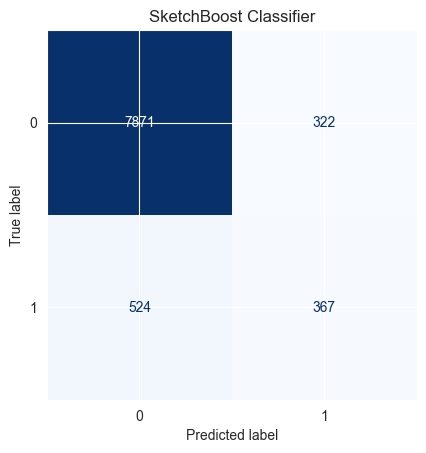

In [49]:
preds_prob = final_sb_model.predict(X_test)


preds_test = (preds_prob > 0.5).astype(int)



ConfusionMatrixDisplay.from_predictions(
    y_test,
    preds_test,
    cmap=plt.cm.Blues,
    colorbar=False
)

plt.title("SketchBoost Classifier")

In [53]:
preds_prob_train = final_sb_model.predict(X_train)
preds_class_train = (preds_prob_train > 0.5).astype(int)

preds_prob_test = final_sb_model.predict(X_test)
preds_class_test = (preds_prob_test > 0.5).astype(int)


train_and_test_comparing.loc["SketchBoost classifier"] = (get_scores(y_train, preds_class_train)
                                                          + get_scores(y_test, preds_class_test))
train_and_test_comparing

Train Data                             \
                                             F1 Accuracy Precision  Recall   
DecisionTreeRegressor (GridSearch)         0.64   0.8941    0.4781  0.9805   
DecisionTreeRegressor (RandomSearch)       0.61   0.8816    0.4490  0.9621   
DecisionTreeRegressor (Optuna)             0.47   0.7859    0.3103  0.9830   
Random Forest (GridSearch)                 0.62   0.8836    0.4545  0.9871   
Random Forest (RandomSearch)               0.62   0.8824    0.4520  0.9870   
Random Forest (Optuna)                     0.62   0.8828    0.4527  0.9871   
Bagging classifier                         0.43   0.8005    0.2968  0.7684   
Gradient Boosting (GridSearch)             0.53   0.8321    0.3652  0.9858   
Gradient Boosting (RandomSearch)           0.53   0.8327    0.3661  0.9858   
Gradient Boosting (Optuna)                 0.53   0.8312    0.3640  0.9850   
AdaBoost (GridSearch)                      0.47   0.7823    0.3075  0.9907   
AdaBoost (RandomSearch)                    0.47   0.7813    0.3067  0.9912   
AdaBoost (Optuna)                          0.47   0.7816    0.3069  0.9911   
Stacking classifier                        0.21   0.9125    0.8735  0.1164   
CatBoost (GridSearch)                      0.51   0.8195    0.3482  0.9834   
CatBoost (RandomSearch)                    0.49   0.8035    0.3291  0.9836   
CatBoost (Optuna)                          0.50   0.8116    0.3384  0.9829   
XGBoost (GridSearch)                       0.55   0.8437    0.3820  0.9841   
XGBoost (RandomSearch)                     0.53   0.8271    0.3583  0.9843   
XGBoost (Optuna)                           0.56   0.8468    0.3868  0.9850   
LightGBM (GridSearch)                      0.53   0.8318    0.3648  0.9864   
LightGBM (RandomSearch)                    0.52   0.8254    0.3561  0.9851   
LightGBM (Optuna)                          0.53   0.8314    0.3644  0.9871   
SketchBoost classifier                     0.93   0.9866    0.9861  0.8748   

                                     Test Data                             
                                            F1 Accuracy Precision  Recall  
DecisionTreeRegressor (GridSearch)        0.50   0.8457    0.3656  0.7800  
DecisionTreeRegressor (RandomSearch)      0.50   0.8427    0.3619  0.7912  
DecisionTreeRegressor (Optuna)            0.48   0.7917    0.3187  0.9877  
Random Forest (GridSearch)                0.52   0.8427    0.3720  0.8777  
Random Forest (RandomSearch)              0.52   0.8437    0.3735  0.8765  
Random Forest (Optuna)                    0.52   0.8407    0.3687  0.8765  
Bagging classifier                        0.43   0.8028    0.3016  0.7677  
Gradient Boosting (GridSearch)            0.50   0.8163    0.3402  0.9293  
Gradient Boosting (RandomSearch)          0.50   0.8165    0.3412  0.9360  
Gradient Boosting (Optuna)                0.50   0.8172    0.3423  0.9383  
AdaBoost (GridSearch)                     0.48   0.7881    0.3155  0.9921  
AdaBoost (RandomSearch)                   0.48   0.7874    0.3149  0.9933  
AdaBoost (Optuna)                         0.48   0.7875    0.3151  0.9933  
Stacking classifier                       0.21   0.9116    0.8548  0.1190  
CatBoost (GridSearch)                     0.49   0.8100    0.3335  0.9383  
CatBoost (RandomSearch)                   0.49   0.8020    0.3274  0.9663  
CatBoost (Optuna)                         0.49   0.8055    0.3297  0.9517  
XGBoost (GridSearch)                      0.50   0.8220    0.3443  0.9012  
XGBoost (RandomSearch)                    0.49   0.8122    0.3346  0.9248  
XGBoost (Optuna)                          0.49   0.8201    0.3409  0.8934  
LightGBM (GridSearch)                     0.49   0.8142    0.3369  0.9237  
LightGBM (RandomSearch)                   0.49   0.8118    0.3337  0.9226  
LightGBM (Optuna)                         0.49   0.8146    0.3369  0.9192  
SketchBoost classifier                    0.46   0.9069    0.5327  0.4119

В целом модель SketchBoost отработала плохо с точки зрения Recall (0.4119).

При этом стоит заметить, что это первая модель, которая смогла сбалансировать значения Recall и Precision (0.5327).

### Pycaret

In [7]:
from pycaret.classification import *

s = setup(data = data, target = "hazardous", session_id=RANDOM_STATE)

,Description,Value
0,Session id,13
1,Target,hazardous
2,Target type,Binary
3,Original data shape,"(90836, 6)"
4,Transformed data shape,"(90836, 6)"
5,Transformed train set shape,"(63585, 6)"
6,Transformed test set shape,"(27251, 6)"
7,Numeric features,5
8,Preprocess,True
9,Imputation type,simple


In [8]:
best_models = compare_models(n_select=5)

,,
,,
Initiated,. . . . . . . . . . . . . . . . . .,19:17:02
Status,. . . . . . . . . . . . . . . . . .,Loading Dependencies
Estimator,. . . . . . . . . . . . . . . . . .,Compiling Library


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.9162,0.9285,0.3938,0.6063,0.4773,0.4340,0.4460,0.8910
catboost,CatBoost Classifier,0.9156,0.9257,0.2495,0.6798,0.3647,0.3298,0.3781,6.2280
lightgbm,Light Gradient Boosting Machine,0.9149,0.9237,0.1934,0.7382,0.3063,0.2772,0.3496,0.1090
et,Extra Trees Classifier,0.9141,0.9263,0.4134,0.5825,0.4835,0.4381,0.4458,0.3370
xgboost,Extreme Gradient Boosting,0.9141,0.9230,0.2557,0.6498,0.3668,0.3300,0.3718,0.1080
gbc,Gradient Boosting Classifier,0.9131,0.9185,0.1469,0.7865,0.2472,0.2235,0.3159,1.1210
ada,Ada Boost Classifier,0.9126,0.9112,0.1653,0.7228,0.2688,0.2414,0.3181,0.3020
svm,SVM - Linear Kernel,0.9027,0.7601,0.0000,0.0000,0.0000,0.0000,0.0000,0.0340
dummy,Dummy Classifier,0.9027,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0180
ridge,Ridge Classifier,0.9026,0.8750,0.0002,0.1000,0.0003,0.0001,0.0016,0.0230


Лучшей моделью по F1 оказалась модель дерева решений, а лучшей моделью по Recall оказалась наивная байсовская модель.

В результатах ЛР наиболее высокие значения F1 показала модель случайного леса с F1 = 0.52, а наивная байесовская модель показала recall = 0.9955.

То есть метрики моделей, полученных в результате ЛР, обладают лучшими метриками.

In [2]:
train_and_test_comparing

Train Data                             \
                                             F1 Accuracy Precision  Recall   
DecisionTreeRegressor (GridSearch)         0.64   0.8941    0.4781  0.9805   
DecisionTreeRegressor (RandomSearch)       0.61   0.8816    0.4490  0.9621   
DecisionTreeRegressor (Optuna)             0.47   0.7859    0.3103  0.9830   
Random Forest (GridSearch)                 0.62   0.8836    0.4545  0.9871   
Random Forest (RandomSearch)               0.62   0.8824    0.4520  0.9870   
Random Forest (Optuna)                     0.62   0.8828    0.4527  0.9871   
Bagging classifier                         0.43   0.8005    0.2968  0.7684   
Gradient Boosting (GridSearch)             0.53   0.8321    0.3652  0.9858   
Gradient Boosting (RandomSearch)           0.53   0.8327    0.3661  0.9858   
Gradient Boosting (Optuna)                 0.53   0.8312    0.3640  0.9850   
AdaBoost (GridSearch)                      0.47   0.7823    0.3075  0.9907   
AdaBoost (RandomSearch)                    0.47   0.7813    0.3067  0.9912   
AdaBoost (Optuna)                          0.47   0.7816    0.3069  0.9911   
Stacking classifier                        0.21   0.9125    0.8735  0.1164   
CatBoost (GridSearch)                      0.51   0.8195    0.3482  0.9834   
CatBoost (RandomSearch)                    0.49   0.8035    0.3291  0.9836   
CatBoost (Optuna)                          0.50   0.8116    0.3384  0.9829   
XGBoost (GridSearch)                       0.55   0.8437    0.3820  0.9841   
XGBoost (RandomSearch)                     0.53   0.8271    0.3583  0.9843   
XGBoost (Optuna)                           0.56   0.8468    0.3868  0.9850   
LightGBM (GridSearch)                      0.53   0.8318    0.3648  0.9864   
LightGBM (RandomSearch)                    0.52   0.8254    0.3561  0.9851   
LightGBM (Optuna)                          0.53   0.8314    0.3644  0.9871   
SketchBoost classifier                     0.93   0.9866    0.9861  0.8748   

                                     Test Data                             
                                            F1 Accuracy Precision  Recall  
DecisionTreeRegressor (GridSearch)        0.50   0.8457    0.3656  0.7800  
DecisionTreeRegressor (RandomSearch)      0.50   0.8427    0.3619  0.7912  
DecisionTreeRegressor (Optuna)            0.48   0.7917    0.3187  0.9877  
Random Forest (GridSearch)                0.52   0.8427    0.3720  0.8777  
Random Forest (RandomSearch)              0.52   0.8437    0.3735  0.8765  
Random Forest (Optuna)                    0.52   0.8407    0.3687  0.8765  
Bagging classifier                        0.43   0.8028    0.3016  0.7677  
Gradient Boosting (GridSearch)            0.50   0.8163    0.3402  0.9293  
Gradient Boosting (RandomSearch)          0.50   0.8165    0.3412  0.9360  
Gradient Boosting (Optuna)                0.50   0.8172    0.3423  0.9383  
AdaBoost (GridSearch)                     0.48   0.7881    0.3155  0.9921  
AdaBoost (RandomSearch)                   0.48   0.7874    0.3149  0.9933  
AdaBoost (Optuna)                         0.48   0.7875    0.3151  0.9933  
Stacking classifier                       0.21   0.9116    0.8548  0.1190  
CatBoost (GridSearch)                     0.49   0.8100    0.3335  0.9383  
CatBoost (RandomSearch)                   0.49   0.8020    0.3274  0.9663  
CatBoost (Optuna)                         0.49   0.8055    0.3297  0.9517  
XGBoost (GridSearch)                      0.50   0.8220    0.3443  0.9012  
XGBoost (RandomSearch)                    0.49   0.8122    0.3346  0.9248  
XGBoost (Optuna)                          0.49   0.8201    0.3409  0.8934  
LightGBM (GridSearch)                     0.49   0.8142    0.3369  0.9237  
LightGBM (RandomSearch)                   0.49   0.8118    0.3337  0.9226  
LightGBM (Optuna)                         0.49   0.8146    0.3369  0.9192  
SketchBoost classifier                    0.46   0.9069    0.5327  0.4119

## Визуализации деревьев

Text(0.5, 1.0, 'Decision Tree')

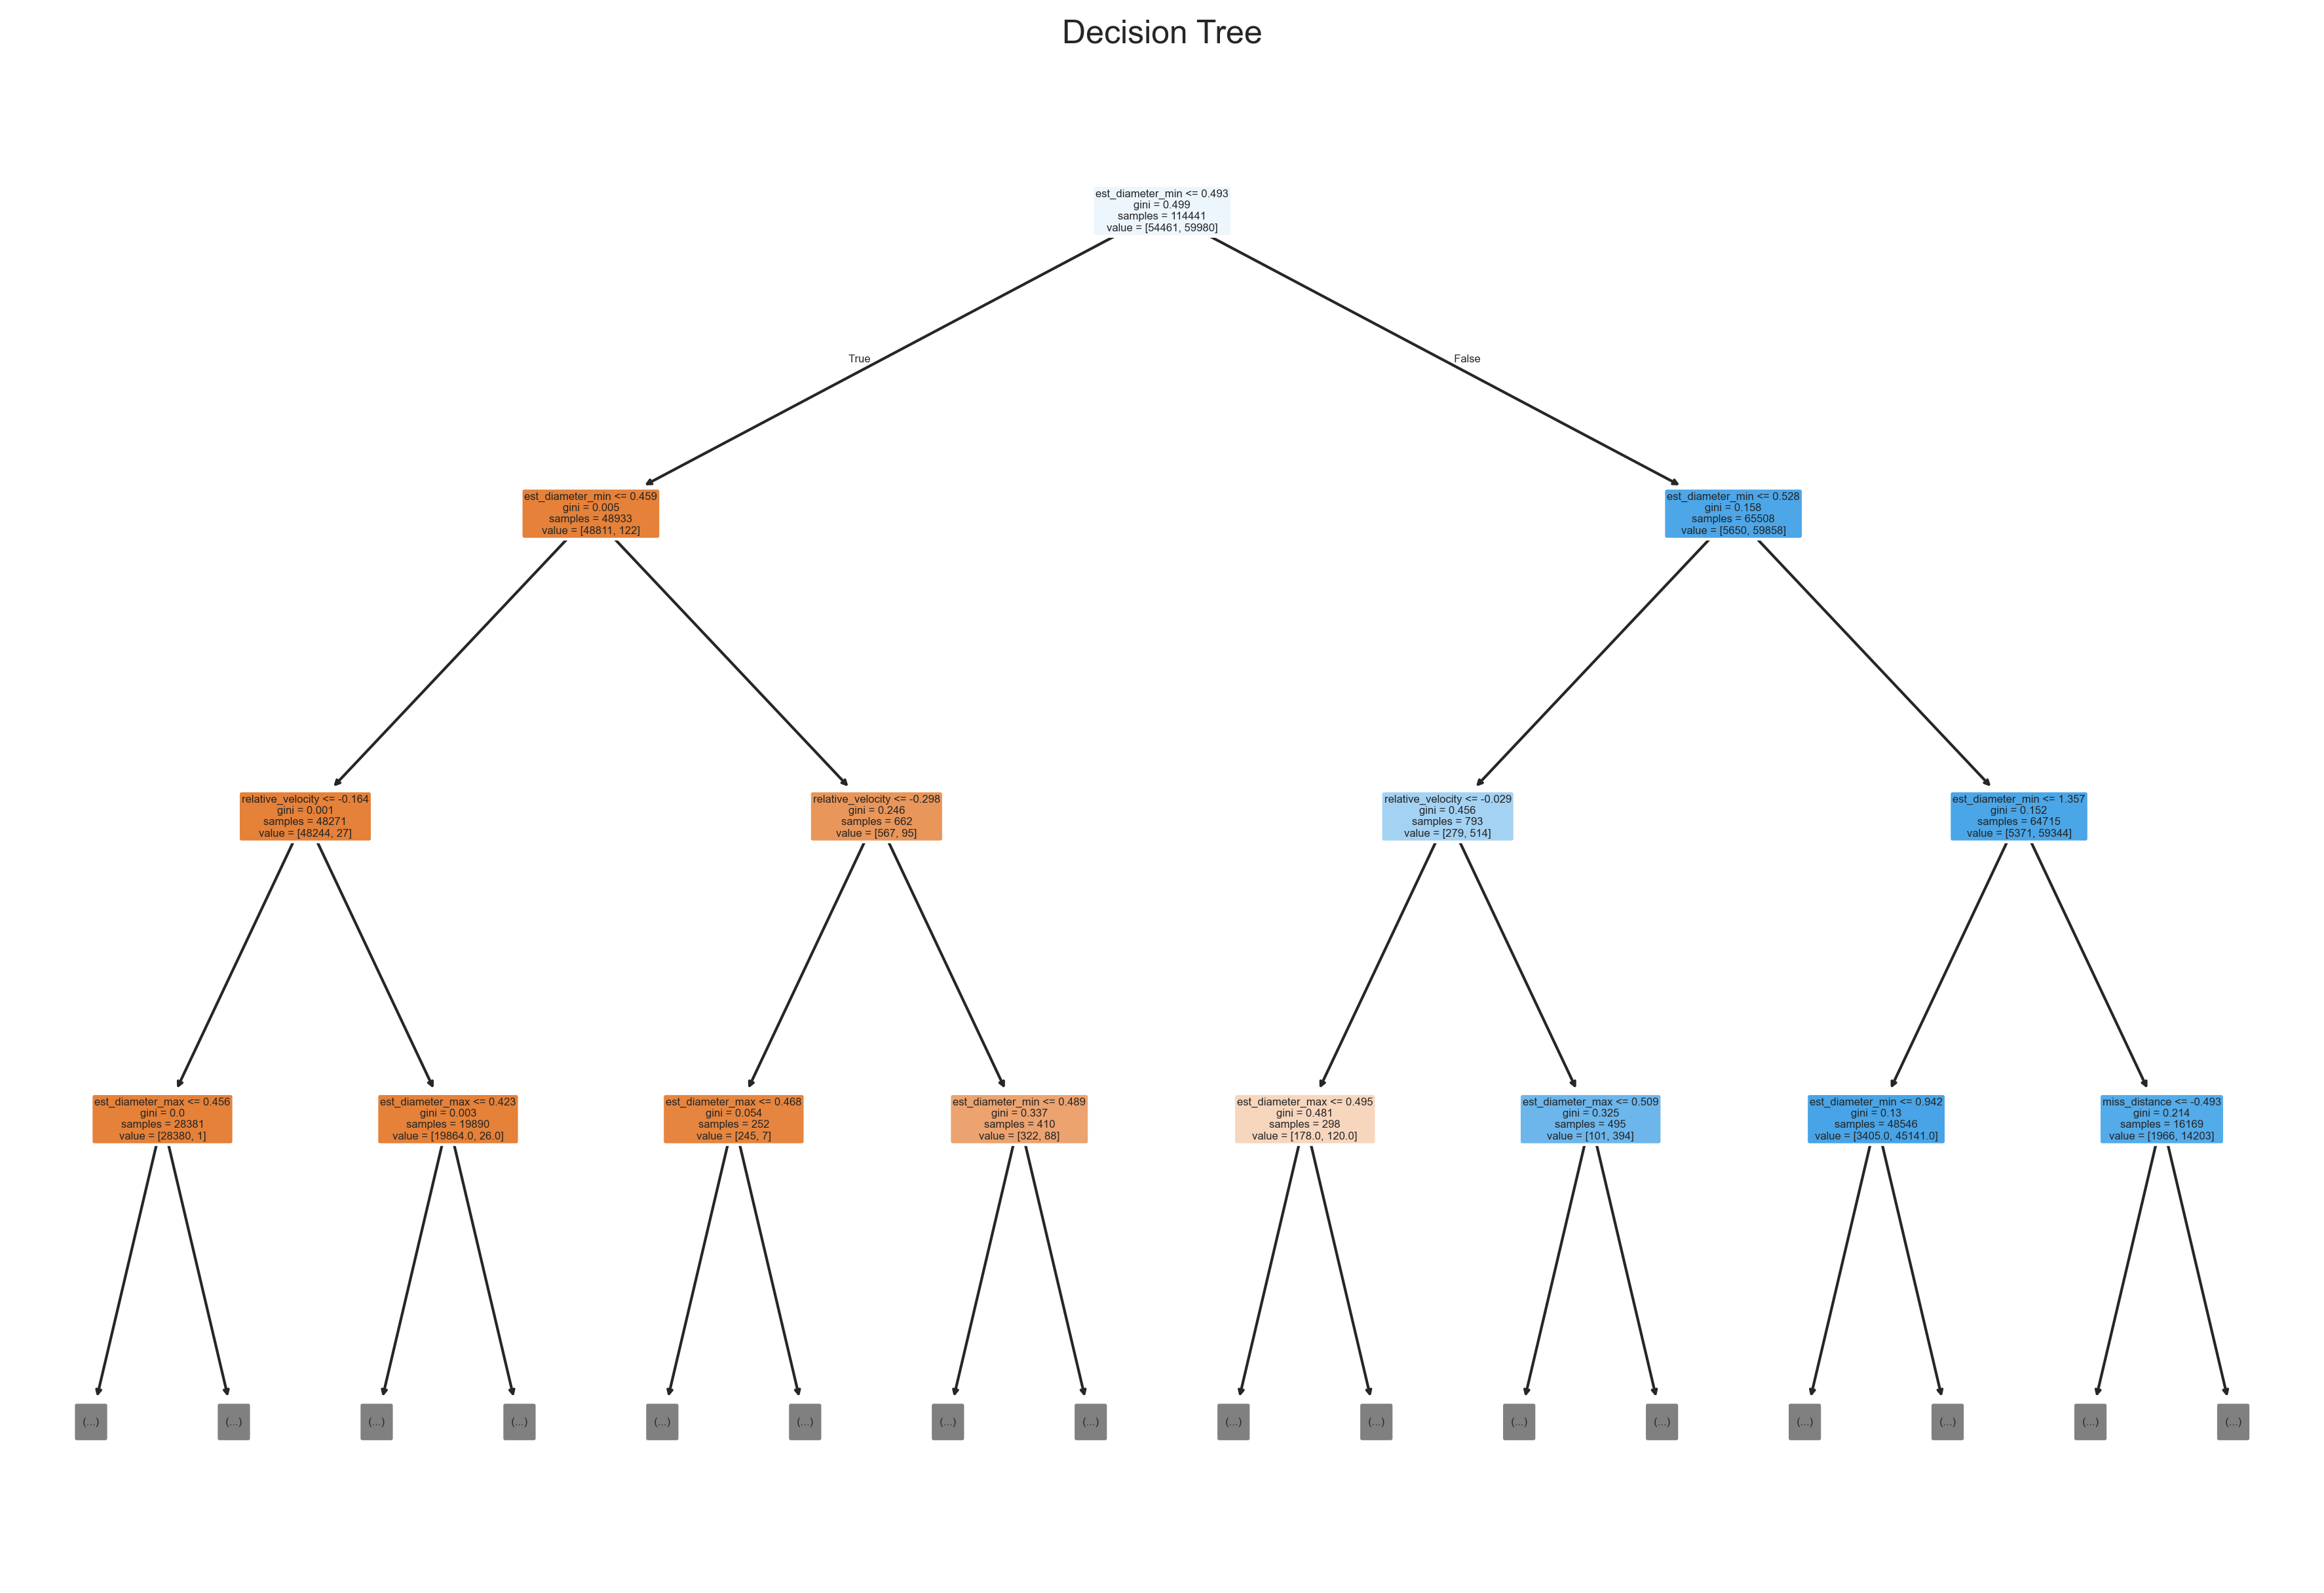

In [41]:
from sklearn import tree

best_tree = dt_models["DT"]["GridSearch"]["model"]["model"]
plt.figure(figsize=(15, 10), dpi=300)

tree.plot_tree(best_tree, feature_names=X.columns,
               max_depth=3, filled=True, rounded=True)

plt.title("Decision Tree")

C:\Users\79585\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names


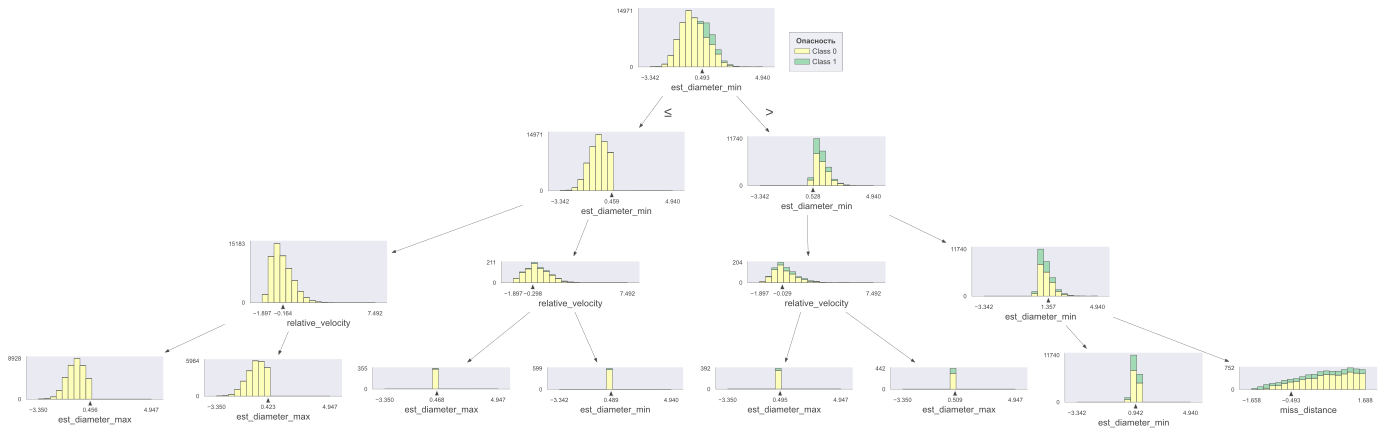

In [91]:
import dtreeviz

viz_model = dtreeviz.model(best_tree,
                           X_train=X, y_train=y,
                           target_name="Опасность",
                           feature_names=X.columns)

viz_model.view(depth_range_to_display=(0, 3))

In [90]:
print(tree.export_text(best_tree, feature_names = X_train.columns))

|--- est_diameter_min <= 0.49
|   |--- est_diameter_min <= 0.46
|   |   |--- relative_velocity <= -0.16
|   |   |   |--- est_diameter_max <= 0.46
|   |   |   |   |--- class: 0
|   |   |   |--- est_diameter_max >  0.46
|   |   |   |   |--- relative_velocity <= -0.58
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- relative_velocity >  -0.58
|   |   |   |   |   |--- relative_velocity <= -0.58
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- relative_velocity >  -0.58
|   |   |   |   |   |   |--- class: 0
|   |   |--- relative_velocity >  -0.16
|   |   |   |--- est_diameter_max <= 0.42
|   |   |   |   |--- absolute_magnitude <= -0.42
|   |   |   |   |   |--- est_diameter_max <= 0.42
|   |   |   |   |   |   |--- absolute_magnitude <= -0.42
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- absolute_magnitude >  -0.42
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- est_diameter_max >  0.42
|   |   |   |   |   |   |--- miss_distance 

Text(0.5, 1.0, 'Decision tree features importances')

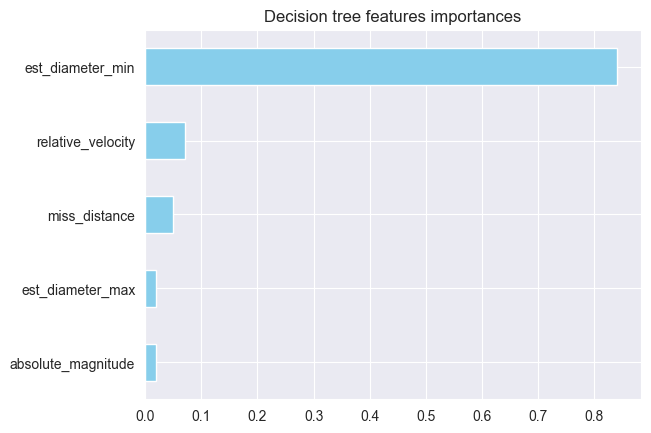

In [43]:
important_features_df = pd.Series(
    best_tree.feature_importances_, index=X_train.columns
).sort_values(ascending=True)

ax = important_features_df.plot.barh(legend=False, color='skyblue')

ax.set_title("Decision tree features importances")

Заметим, что дерево главным образом характеризует опасность объекта по его размерам - прочие характеристики имеют гораздо меньшее значение.

Text(0.5, 1.0, 'Визуализация одного дерева из Random Forest')

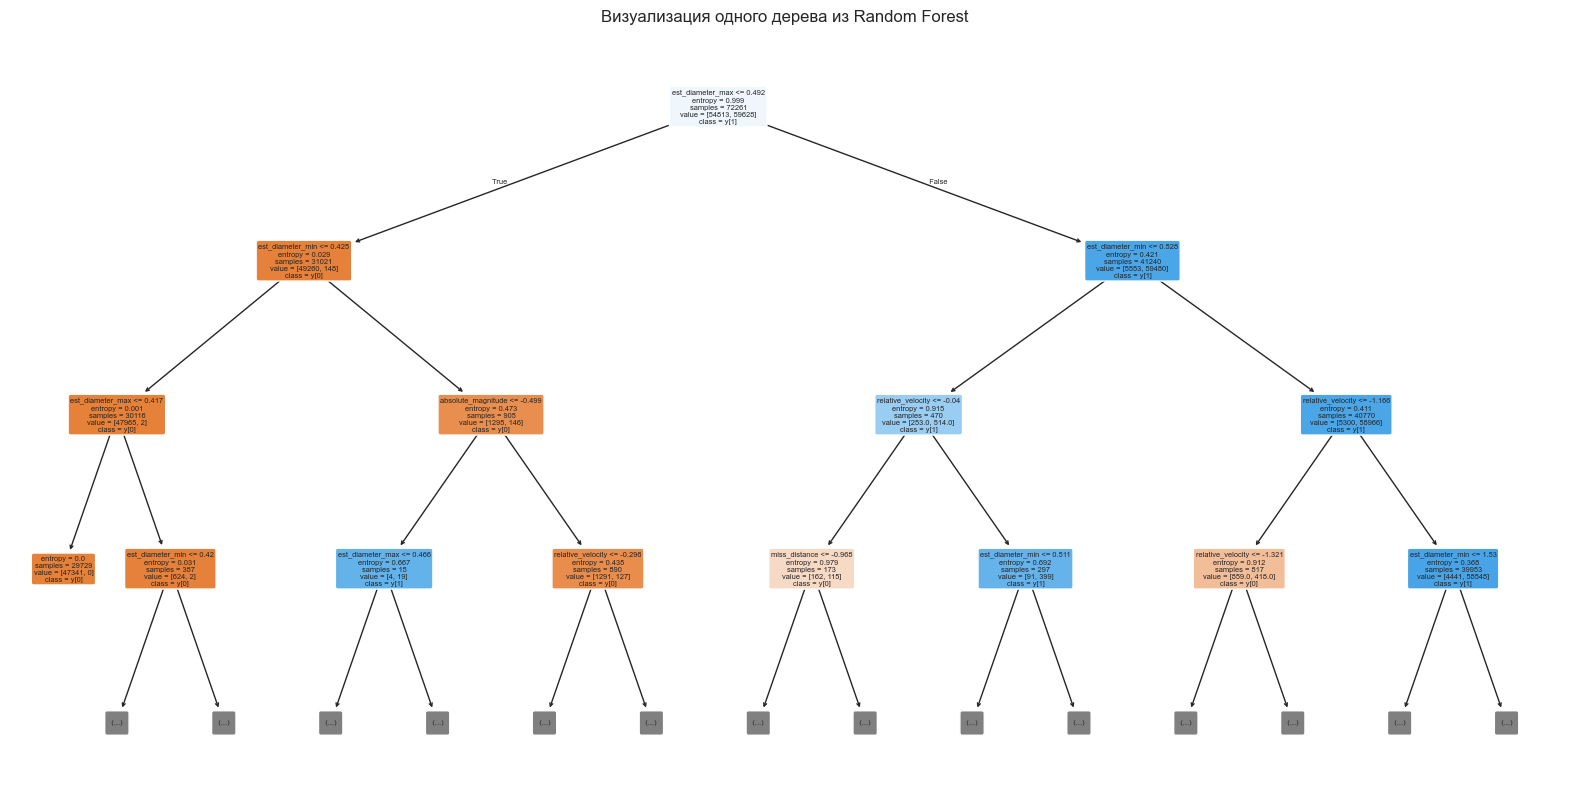

In [42]:
rf_best_model = rf_models["RF"]["GridSearch"]["model"]["model"]
chosen_tree = rf_best_model.estimators_[0]

plt.figure(figsize=(20, 10))
tree.plot_tree(chosen_tree,
               feature_names=X_train.columns,
               class_names=True,
               filled=True,
               rounded=True,
               max_depth=3)
plt.title("Визуализация одного дерева из Random Forest")

Text(0.5, 1.0, 'Random Forest features importances')

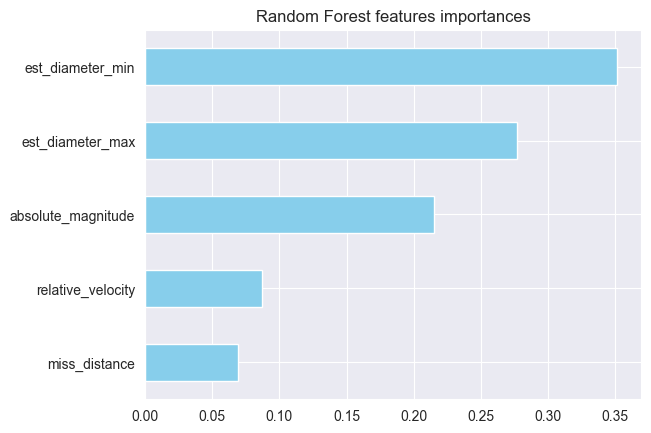

In [55]:
rf_important_features_df = pd.Series(
    rf_best_model.feature_importances_, index=X_train.columns
).sort_values(ascending=True)

ax = rf_important_features_df.plot.barh(legend=False, color='skyblue')

ax.set_title("Random Forest features importances")

Модель случайного леса учитывает в своих предсказаниях размеры объекта и его абсолютную звездную величину. В целом эта модель лучше учитывает значимость признаков, чем дерево решений.

Text(0.5, 1.0, 'Gradient Bossting features importances')

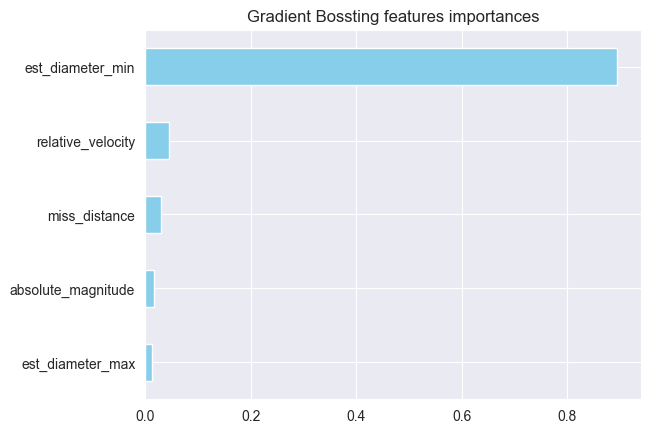

In [51]:
gb_best_model = gb_models["Gradient Boosting"]["GridSearch"]["model"]["model"]

gb_important_features_df = pd.Series(
    gb_best_model.feature_importances_, index=X_train.columns
).sort_values(ascending=True)

ax = gb_important_features_df.plot.barh(legend=False, color='skyblue')

ax.set_title("Gradient Bossting features importances")

Модель градиентного бустинга также рассматривает минимальную оценку диаметра объекта как основной предиктор опасности.

Text(0.5, 1.0, 'AdaBoost features importances')

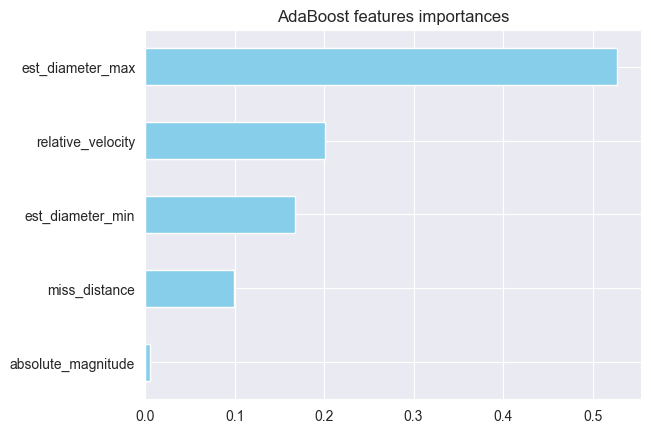

In [54]:
ab_best_model = ab_models["AdaBoost"]["Optuna"]["model"]["model"]

ab_important_features_df = pd.Series(
    ab_best_model.feature_importances_, index=X_train.columns
).sort_values(ascending=True)

ax = ab_important_features_df.plot.barh(legend=False, color='skyblue')

ax.set_title("AdaBoost features importances")

Модель AdaBoost в большей мере ориентируется на значения верхней оценки диаметра, а также скорости.

In [66]:
head_of_table = []

for val in ["hold-out", "KFold"]:
    for metric in metrics:
        head_of_table.append(val + " " + metric)

hold_kross_table = pd.DataFrame(columns=head_of_table)
hold_kross_table

,hold-out F1,hold-out Accuracy,hold-out Precision,hold-out Recall,KFold F1,KFold Accuracy,KFold Precision,KFold Recall


In [73]:
best_models = [best_tree,
               rf_models["RF"]["Optuna"]["model"],
               ab_models["AdaBoost"]["Optuna"]["model"],
               gb_models["Gradient Boosting"]["GridSearch"]["model"],
               cb_models["CatBoost"]["GridSearch"]["model"],
               xgb_models["XGBoost"]["Optuna"]["model"],
               lgbm_models["LightGBM"]["GridSearch"]["model"],]

name_of_models = ["Decision Tree","Random Forest", "AdaBoost",
                  "Gradient Boosting", "CatBoost", "XGBoost",
                  "LightGBM"]

for name_of_model, model in zip(name_of_models, best_models):
    val_predict = model.predict(X_val)
    val_metrics = get_scores(y_val, val_predict)

    test_predict = model.predict(X_test)
    test_metrics = get_scores(y_test, test_predict)
    hold_kross_table.loc[name_of_model] = val_metrics + test_metrics

preds_prob_val = final_sb_model.predict(X_val)
preds_class_val = (preds_prob_val > 0.5).astype(int)

preds_prob_test = final_sb_model.predict(X_test)
preds_class_test = (preds_prob_test > 0.5).astype(int)


hold_kross_table.loc["SketchBoost classifier"] = (get_scores(y_val, preds_class_val)
                                                          + get_scores(y_test, preds_class_test))

hold_kross_table

,hold-out F1,hold-out Accuracy,hold-out Precision,hold-out Recall,KFold F1,KFold Accuracy,KFold Precision,KFold Recall
Decision Tree,0.51,0.8486,0.3710,0.7935,0.50,0.8457,0.3656,0.7800
Random Forest,0.52,0.8402,0.3661,0.8736,0.52,0.8407,0.3687,0.8765
AdaBoost,0.47,0.7814,0.3069,0.9865,0.48,0.7875,0.3151,0.9933
Gradient Boosting,0.50,0.8138,0.3382,0.9492,0.50,0.8163,0.3402,0.9293
CatBoost,0.49,0.8065,0.3292,0.9481,0.49,0.8100,0.3335,0.9383
XGBoost,0.50,0.8229,0.3446,0.9052,0.49,0.8201,0.3409,0.8934
LightGBM,0.49,0.8114,0.3318,0.9210,0.49,0.8142,0.3369,0.9237
SketchBoost classifier,0.44,0.9093,0.5533,0.3634,0.46,0.9069,0.5327,0.4119


C:\Users\79585\AppData\Local\Temp\ipykernel_17132\3662364013.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



Text(0, 0.5, '')

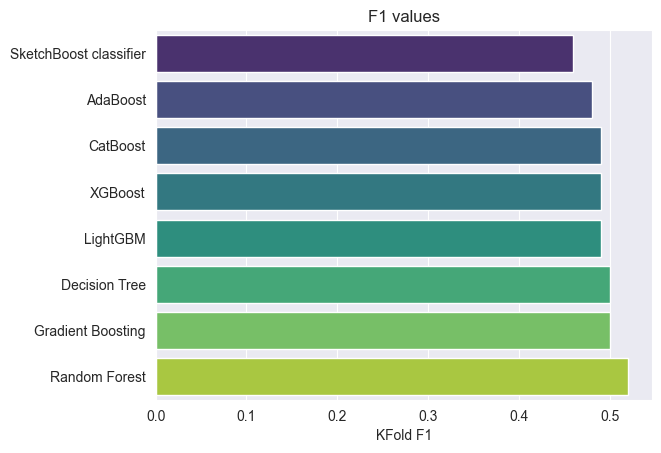

In [88]:
sns.barplot(
    x='KFold F1',
    y=hold_kross_table.index,
    data=hold_kross_table.sort_values(by='KFold F1', ascending=True),
)

plt.title("F1 values")

C:\Users\79585\AppData\Local\Temp\ipykernel_17132\2323413021.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



Text(0, 0.5, '')

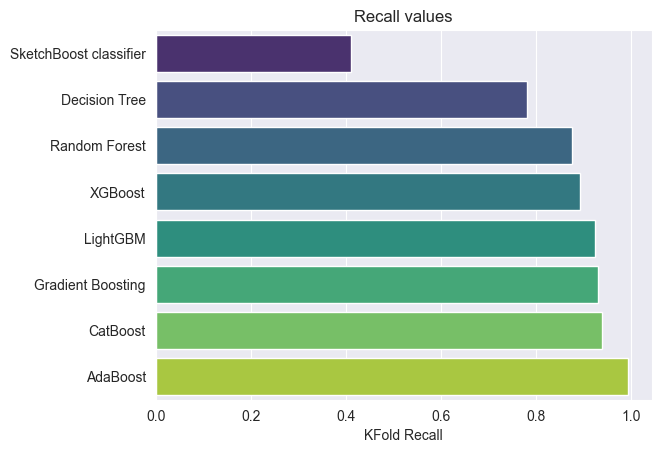

In [89]:
sns.barplot(
    x='KFold Recall',
    y=hold_kross_table.index,
    data=hold_kross_table.sort_values(by='KFold Recall', ascending=True),
)

plt.title("Recall values")

## Вывод

Лучшей моделью по значению Recall можно считать модель AdaBoost, так как именно она минимизирует количество ошибок второго рода, тем самым по ее предсказаниям будет пропущено как можно меньше опасных объектов.

При этом лучшей моделью с точки зрения F1 оказалась модель случайного леса. Но стоит учитывать, что в контексте предметной области значение Recall важнее, так как лучше определить неопасный объект как опасный, чем опасный объект как неопасный.

Стоит отметить, что в виду сложности предметной области опасные и неопасные астероиды сложно определить в соответствии с признаками, представленными в датасете. Поэтому опасные и неопасные объекты становятся тяжело определимыми в зависимости от данных предикторов. Это объясняет низкие показатели метрики F1.